# CNN FEAR & GREED INDEX FOR XLK ETF FORECASTING
Author: Simão Soberano Barata Azevedo Varandas

Date: April 2026

Research Question: Does Fear & Greed improve GJR-GARCH-X forecasts beyond VIX?

# SECTION 1: IMPORTS AND CONFIGURATIONS


In [1]:
# 1.1 Standard Libraries
import os
import warnings
from datetime import datetime
import sys

# 1.2 Data Science Stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

# 1.3 Statistical Models

!pip install arch
from sklearn.linear_model import LinearRegression
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except ImportError:
    ARCH_AVAILABLE = False
    print("Warning: 'arch' library not available. Skipping validation checks.")

# 1.4 Plotting Configuration
warnings.filterwarnings('ignore')  # Suppress optimization warnings for clean output
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

print("=" * 80)
print("THESIS: CNN FEAR & GREED INDEX FOR TECH VOLATILITY FORECASTING")
print("=" * 80)
print(f"Execution started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 40.3 MB/s eta 0:00:00
THESIS: CNN FEAR & GREED INDEX FOR TECH VOLATILITY FORECASTING
Execution started: 2026-03-18 15:49:42



# SECTION 2: DATA LOADING, PREPROCESSING & VALIDATION
### Source F&G + VIX: Whit3Rabbit GitHub repo (CNN Fear & Greed + VIX/SPY)
###         https://github.com/whit3rabbit/fear-greed-data
### Source XLK: yfinance (official adjusted closes)

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import os
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("SECTION 2: DATA LOADING & PREPROCESSING & VALIDATION")
print("=" * 80)

# =============================================================================
# 2.1. LOAD RAW DATA (Direct from sources)
# =============================================================================

github_url = "https://raw.githubusercontent.com/whit3rabbit/fear-greed-data/main/datasets/combined/spy_vix_fear_greed_2011_2023.csv"
df_raw = pd.read_csv(github_url, parse_dates=['Date'])
print(f"Whit3Rabbit repo loaded: {len(df_raw)} rows ({df_raw['Date'].min()} to {df_raw['Date'].max()})")

df = df_raw[['Date', 'Adj Close_VIX', 'Fear Greed']].copy()
df.columns = ['Date', 'VIX', 'FNG']
print(f"  Fear Greed range: {df['FNG'].min():.1f} - {df['FNG'].max():.1f}")
print(f"  Fear Greed zeros: {(df['FNG'] == 0).sum()}")

end_date = df['Date'].max()
xlk = yf.download("XLK", start="2011-01-01", end=end_date + pd.Timedelta(days=1), progress=False)
xlk.columns = xlk.columns.droplevel(1)
xlk = xlk[['Close']].reset_index().rename(columns={'Date': 'Date', 'Close': 'XLK_price'})

df = xlk.merge(df, on='Date', how='inner')
print(f"Final dataset: {len(df)} days ({df['Date'].min().date()} to {df['Date'].max().date()})")


# =============================================================================
# 2.2. FEATURE ENGINEERING & PREPROCESSING
# =============================================================================

print("\n2.1 Log Returns")
df['Log_Return'] = np.log(df['XLK_price'] / df['XLK_price'].shift(1))
print(f"  Log returns: mean={df['Log_Return'].mean():.6f}, std={df['Log_Return'].std():.6f}")

# Invert Fear & Greed so high = fear (consistent direction with VIX)
df['FearIndex'] = 100 - df['FNG']

# Drop NaN from log returns before split
df = df.dropna(subset=['Log_Return', 'VIX', 'FearIndex'])

print(f"  Pre-scaling corr(VIX, FearIndex): {df[['VIX','FearIndex']].corr().iloc[0,1]:.3f}")


# =============================================================================
# 2.3. TRAIN/TEST SPLIT (before any scaling to prevent leakage)
# =============================================================================

print("\n2.3 Train/Test Split (80-20)")
split_idx = int(len(df) * 0.8)
train_data = df.iloc[:split_idx].copy()
test_data = df.iloc[split_idx:].copy()

print(f"  Train: {len(train_data)} obs ({train_data['Date'].min().date()} to {train_data['Date'].max().date()})")
print(f"  Test:  {len(test_data)} obs ({test_data['Date'].min().date()} to {test_data['Date'].max().date()})")
print(f"  Test period coverage: {len(test_data)/len(df)*100:.1f}% of total data")


# =============================================================================
# 2.4. STANDARDIZATION (training parameters only, applied to full dataset)
# =============================================================================

print("\n2.4 Standardization (using training mean and std only)")

vix_mean = train_data['VIX'].mean()
vix_std  = train_data['VIX'].std()
fear_mean = train_data['FearIndex'].mean()
fear_std  = train_data['FearIndex'].std()

print(f"  VIX training stats    | mean: {vix_mean:.4f}  std: {vix_std:.4f}")
print(f"  FearIndex training stats | mean: {fear_mean:.4f}  std: {fear_std:.4f}")

# Apply training parameters to full dataset
df['VIXScaled']   = (df['VIX'] - vix_mean) / vix_std
df['FearScaled']  = (df['FearIndex'] - fear_mean) / fear_std

# Verification
print("\n--- SCALING VERIFICATION ---")
print(f"VIX raw        | min: {df['VIX'].min():.2f}   max: {df['VIX'].max():.2f}   mean: {df['VIX'].mean():.2f}")
print(f"VIXScaled      | min: {df['VIXScaled'].min():.4f}  max: {df['VIXScaled'].max():.4f}  mean: {df['VIXScaled'].mean():.4f}")
print(f"FearIndex raw  | min: {df['FearIndex'].min():.2f}   max: {df['FearIndex'].max():.2f}   mean: {df['FearIndex'].mean():.2f}")
print(f"FearScaled     | min: {df['FearScaled'].min():.4f}  max: {df['FearScaled'].max():.4f}  mean: {df['FearScaled'].mean():.4f}")
print(f"Log_Return     | min: {df['Log_Return'].min():.4f}  max: {df['Log_Return'].max():.4f}  mean: {df['Log_Return'].mean():.6f}")
print(f"\nStd check — training set should be ~1.0 after standardization:")
train_temp = df.iloc[:split_idx]
print(f"  VIXScaled std (train):  {train_temp['VIXScaled'].std():.4f}")
print(f"  FearScaled std (train): {train_temp['FearScaled'].std():.4f}")
print("--- END SCALING VERIFICATION ---\n")


# =============================================================================
# 2.5. ORTHOGONALIZATION (on training data only)
# =============================================================================

print("\n2.5 Orthogonalization (isolate Fear signal independent of VIX)")

train_clean = df.iloc[:split_idx][['VIXScaled', 'FearScaled']].dropna()
reg = LinearRegression().fit(train_clean[['VIXScaled']], train_clean['FearScaled'])

# Apply using training regression coefficients to full dataset
df['FearOrth'] = df['FearScaled'] - reg.predict(df[['VIXScaled']])

print(f"  Regression coefficient (training): beta={reg.coef_[0]:.4f}")
print(f"  R-squared (training): {reg.score(train_clean[['VIXScaled']], train_clean['FearScaled']):.4f}")

# Rebuild train/test with all new columns
train_data = df.iloc[:split_idx].copy()
test_data  = df.iloc[split_idx:].copy()

train_corr = train_data[['VIXScaled', 'FearOrth']].corr().iloc[0,1]
print(f"  Post-orthogonalization corr (training): {train_corr:.6f}")
if abs(train_corr) < 0.01:
    print("  Independence achieved in training data")


# =============================================================================
# 2.6. QUALITY CHECKS
# =============================================================================

print("\n2.6 Quality Checks:")
print(f"  Missing values in train: {train_data[['Log_Return','VIXScaled','FearOrth']].isnull().sum().sum()}")
print(f"  Missing values in test:  {test_data[['Log_Return','VIXScaled','FearOrth']].isnull().sum().sum()}")

adf = adfuller(train_data['Log_Return'].dropna())
print(f"  ADF test (Log_Return): stat={adf[0]:.4f}, p-value={adf[1]:.4f}")
print(f"  Critical values: 1%={adf[4]['1%']:.3f}, 5%={adf[4]['5%']:.3f}")
if adf[1] < 0.05:
    print("  Result: Series is stationary (reject unit root hypothesis)")

outlier_threshold = 5
outliers = (np.abs(train_data['Log_Return']) > outlier_threshold * train_data['Log_Return'].std()).sum()
print(f"  Outliers (|return| > {outlier_threshold}sigma) in training: {outliers}")


# =============================================================================
# 2.7. SAVE
# =============================================================================

df.to_csv("thesis_dataset_clean.csv", index=False)

# Also save train/test separately for R
train_data.to_csv("train_data_for_R.csv", index=False)
test_data.to_csv("test_data_for_R.csv", index=False)

print("\nSAVED: thesis_dataset_clean.csv")
print("SAVED: train_data_for_R.csv")
print("SAVED: test_data_for_R.csv")
print("=" * 80)
print("DATA PREPROCESSING COMPLETE - Ready for GARCH modeling")
print("=" * 80)

SECTION 2: DATA LOADING & PREPROCESSING & VALIDATION
Whit3Rabbit repo loaded: 3270 rows (2011-01-03 00:00:00 to 2023-12-29 00:00:00)
  Fear Greed range: 0.0 - 97.0
  Fear Greed zeros: 1
Final dataset: 3270 days (2011-01-03 to 2023-12-29)

2.1 Log Returns
  Log returns: mean=0.000676, std=0.013511
  Pre-scaling corr(VIX, FearIndex): 0.445

2.3 Train/Test Split (80-20)
  Train: 2597 obs (2011-01-04 to 2021-06-01)
  Test:  650 obs (2021-06-02 to 2023-12-29)
  Test period coverage: 20.0% of total data

2.4 Standardization (using training mean and std only)
  VIX training stats    | mean: 17.5651  std: 7.3160
  FearIndex training stats | mean: 50.3916  std: 22.0062

--- SCALING VERIFICATION ---
VIX raw        | min: 9.14   max: 82.69   mean: 18.18
VIXScaled      | min: -1.1516  max: 8.9017  mean: 0.0838
FearIndex raw  | min: 3.00   max: 100.00   mean: 51.16
FearScaled     | min: -2.1536  max: 2.2543  mean: 0.0350
Log_Return     | min: -0.1487  max: 0.1109  mean: 0.000661

Std check — traini

# Report Visualisations

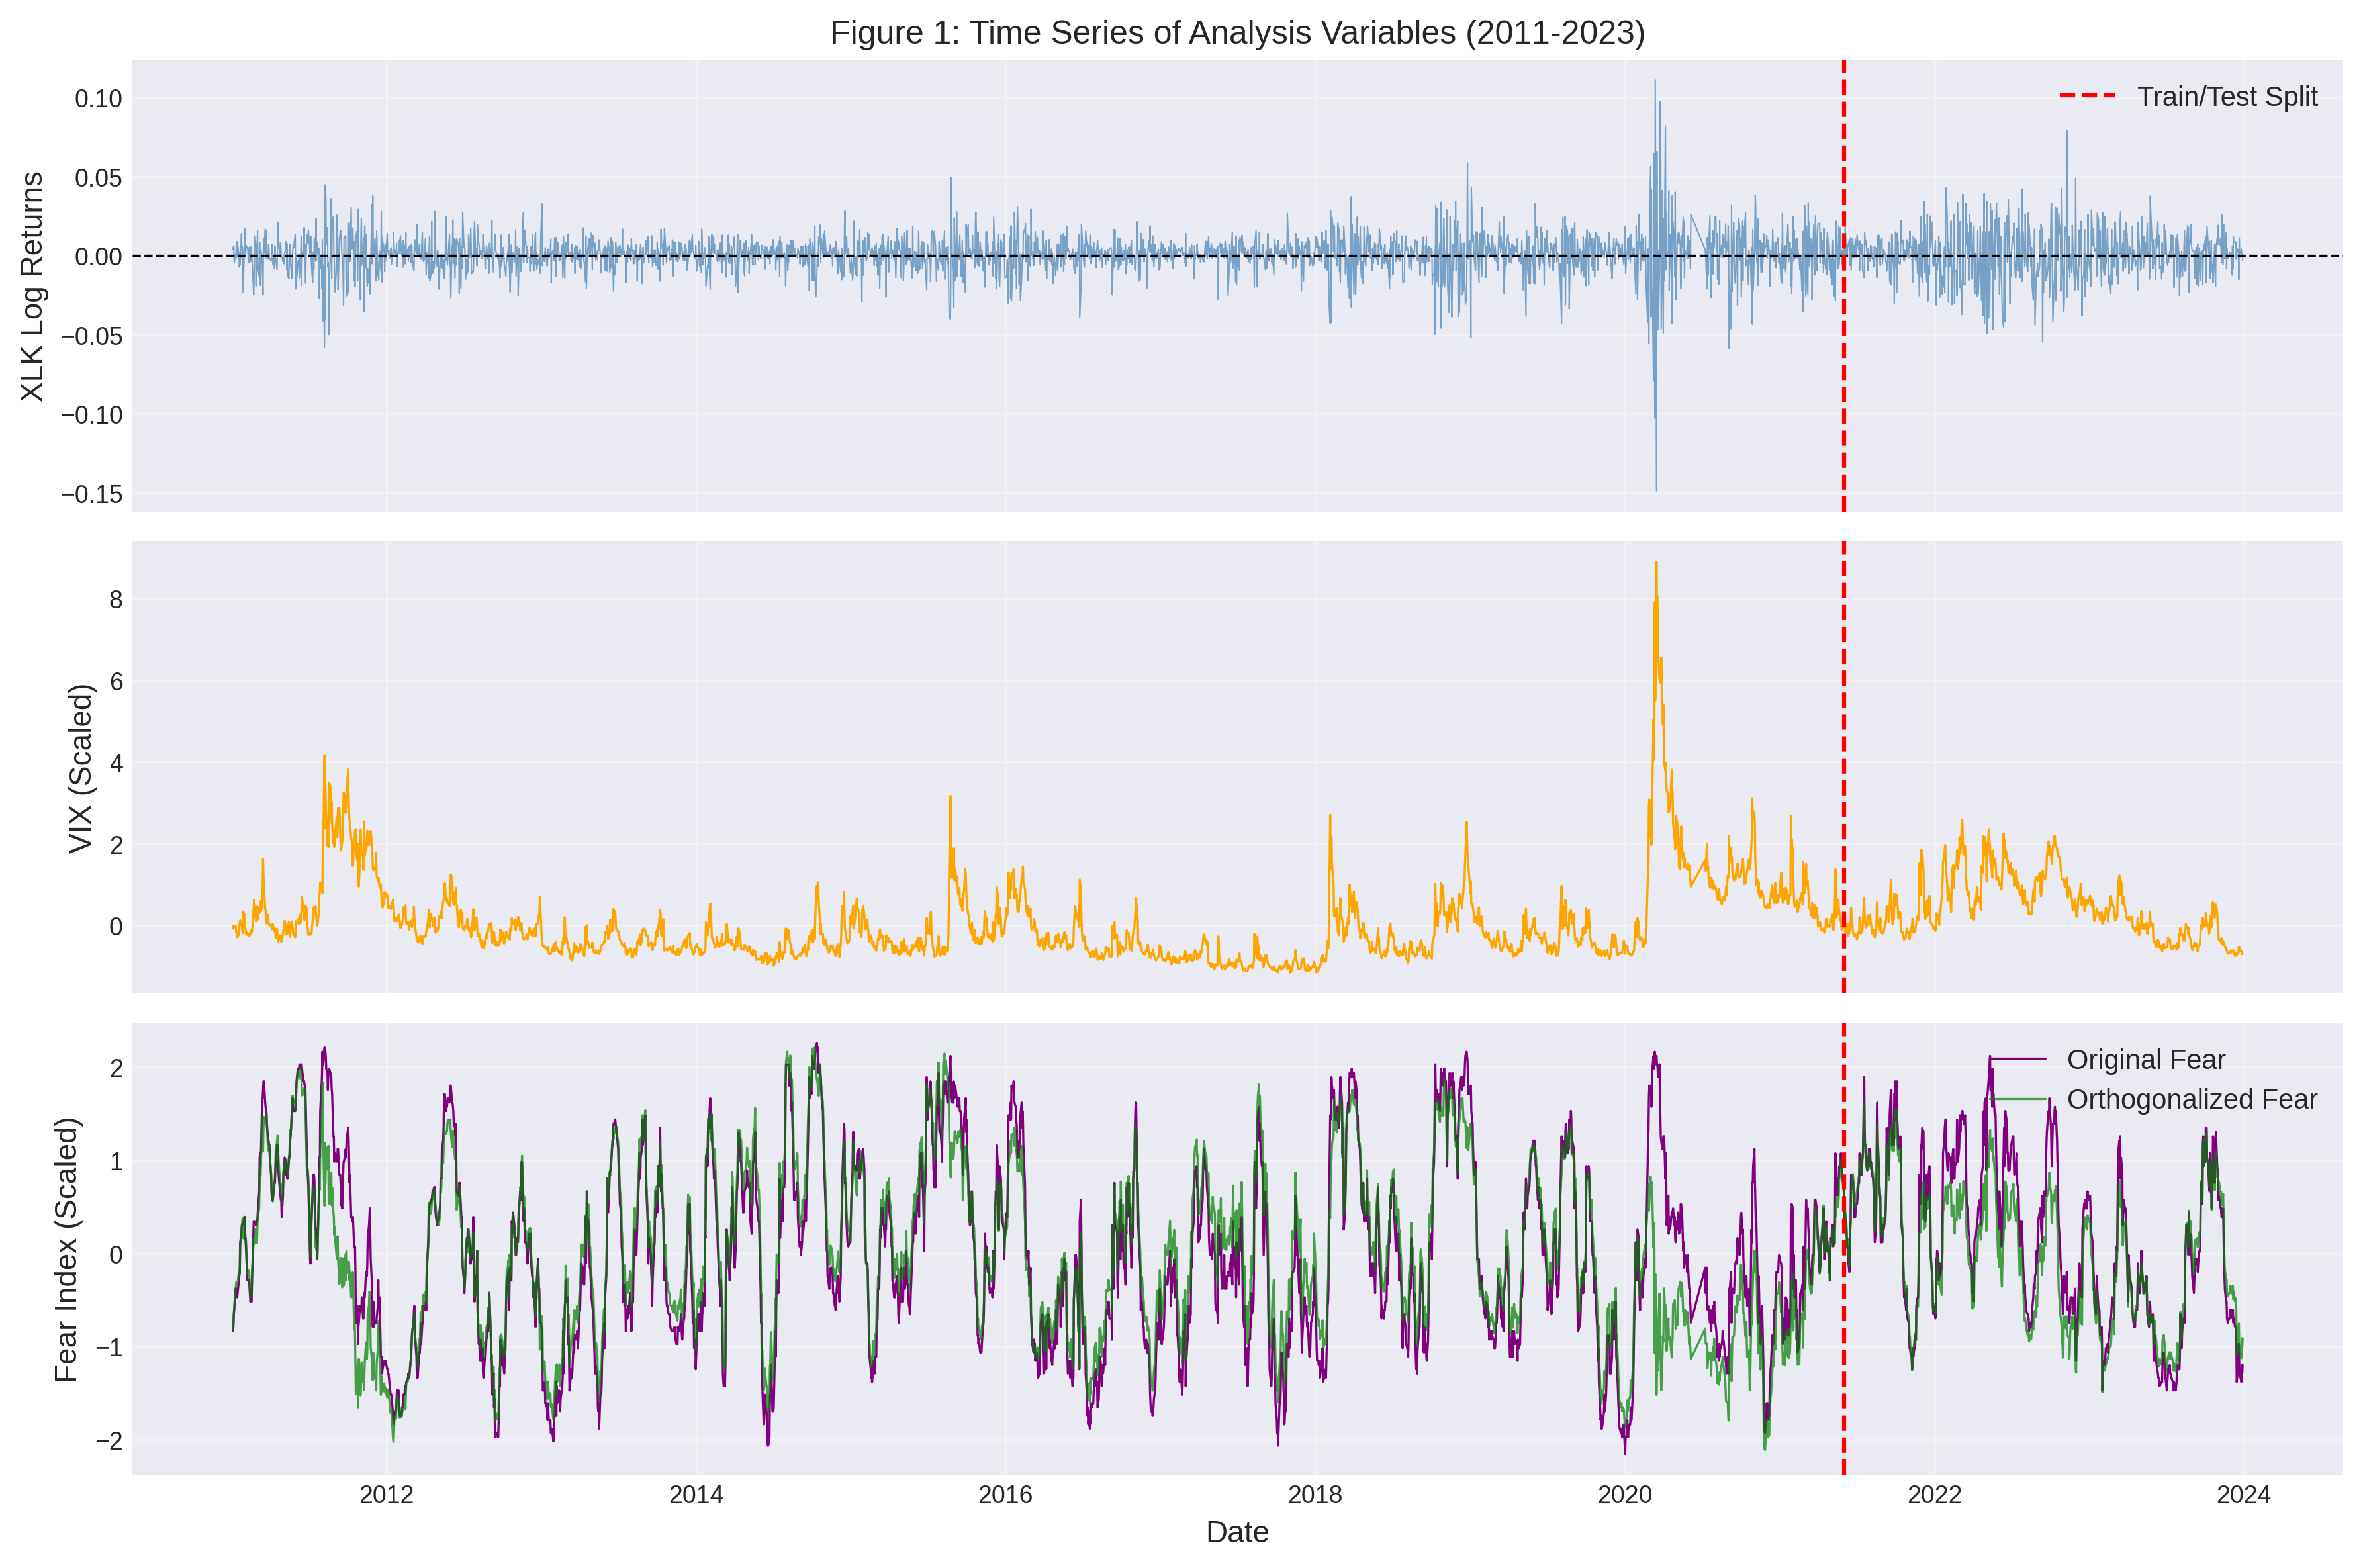

SAVED: methodology_fig1_timeseries.png


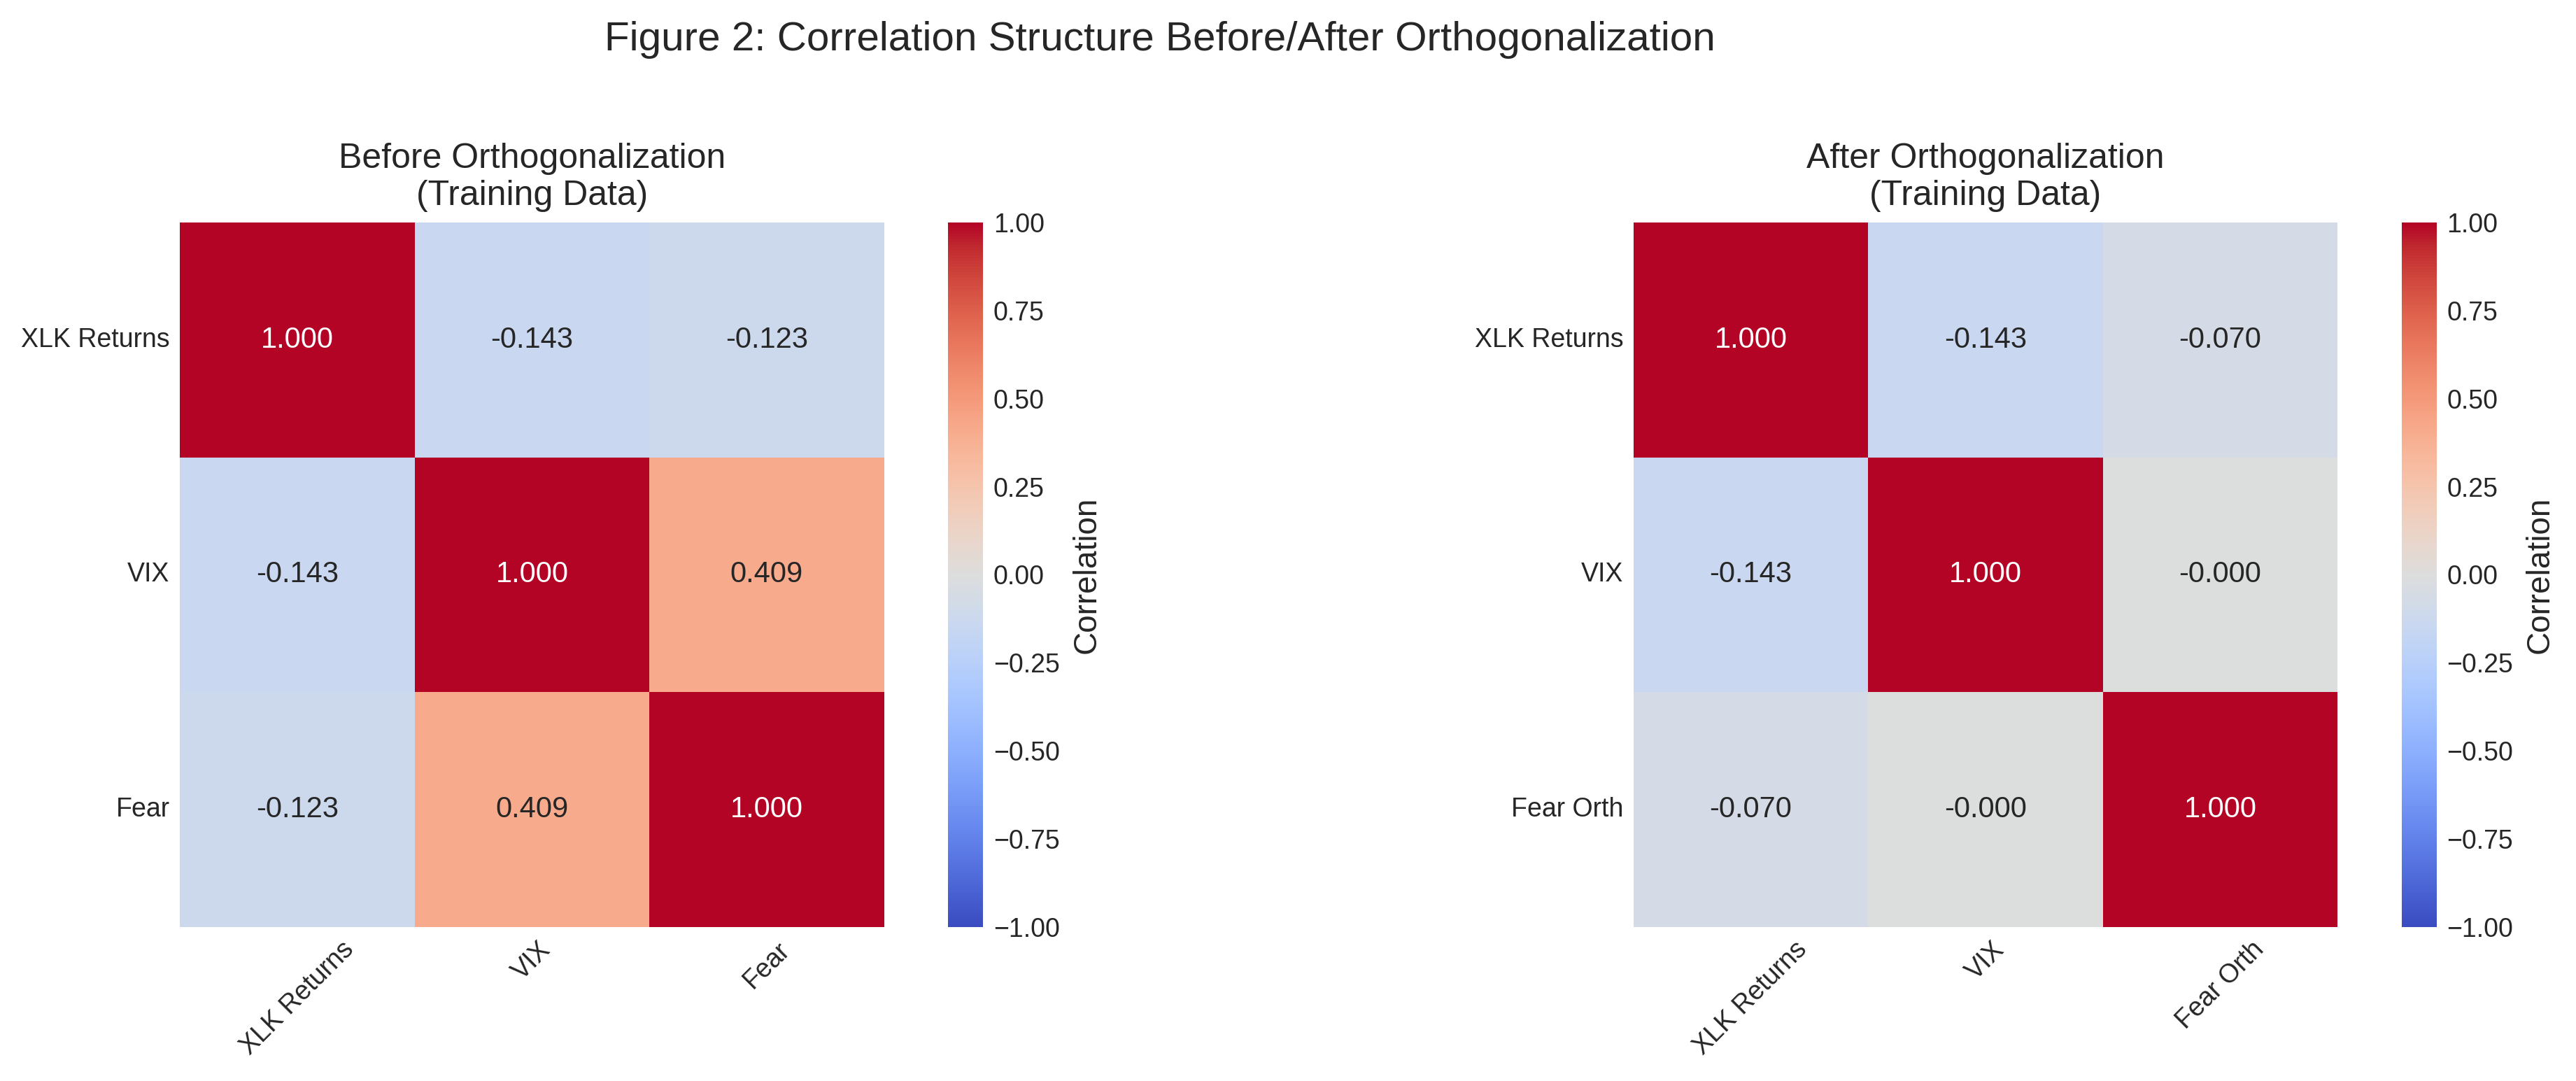

SAVED: methodology_fig2_correlations.png


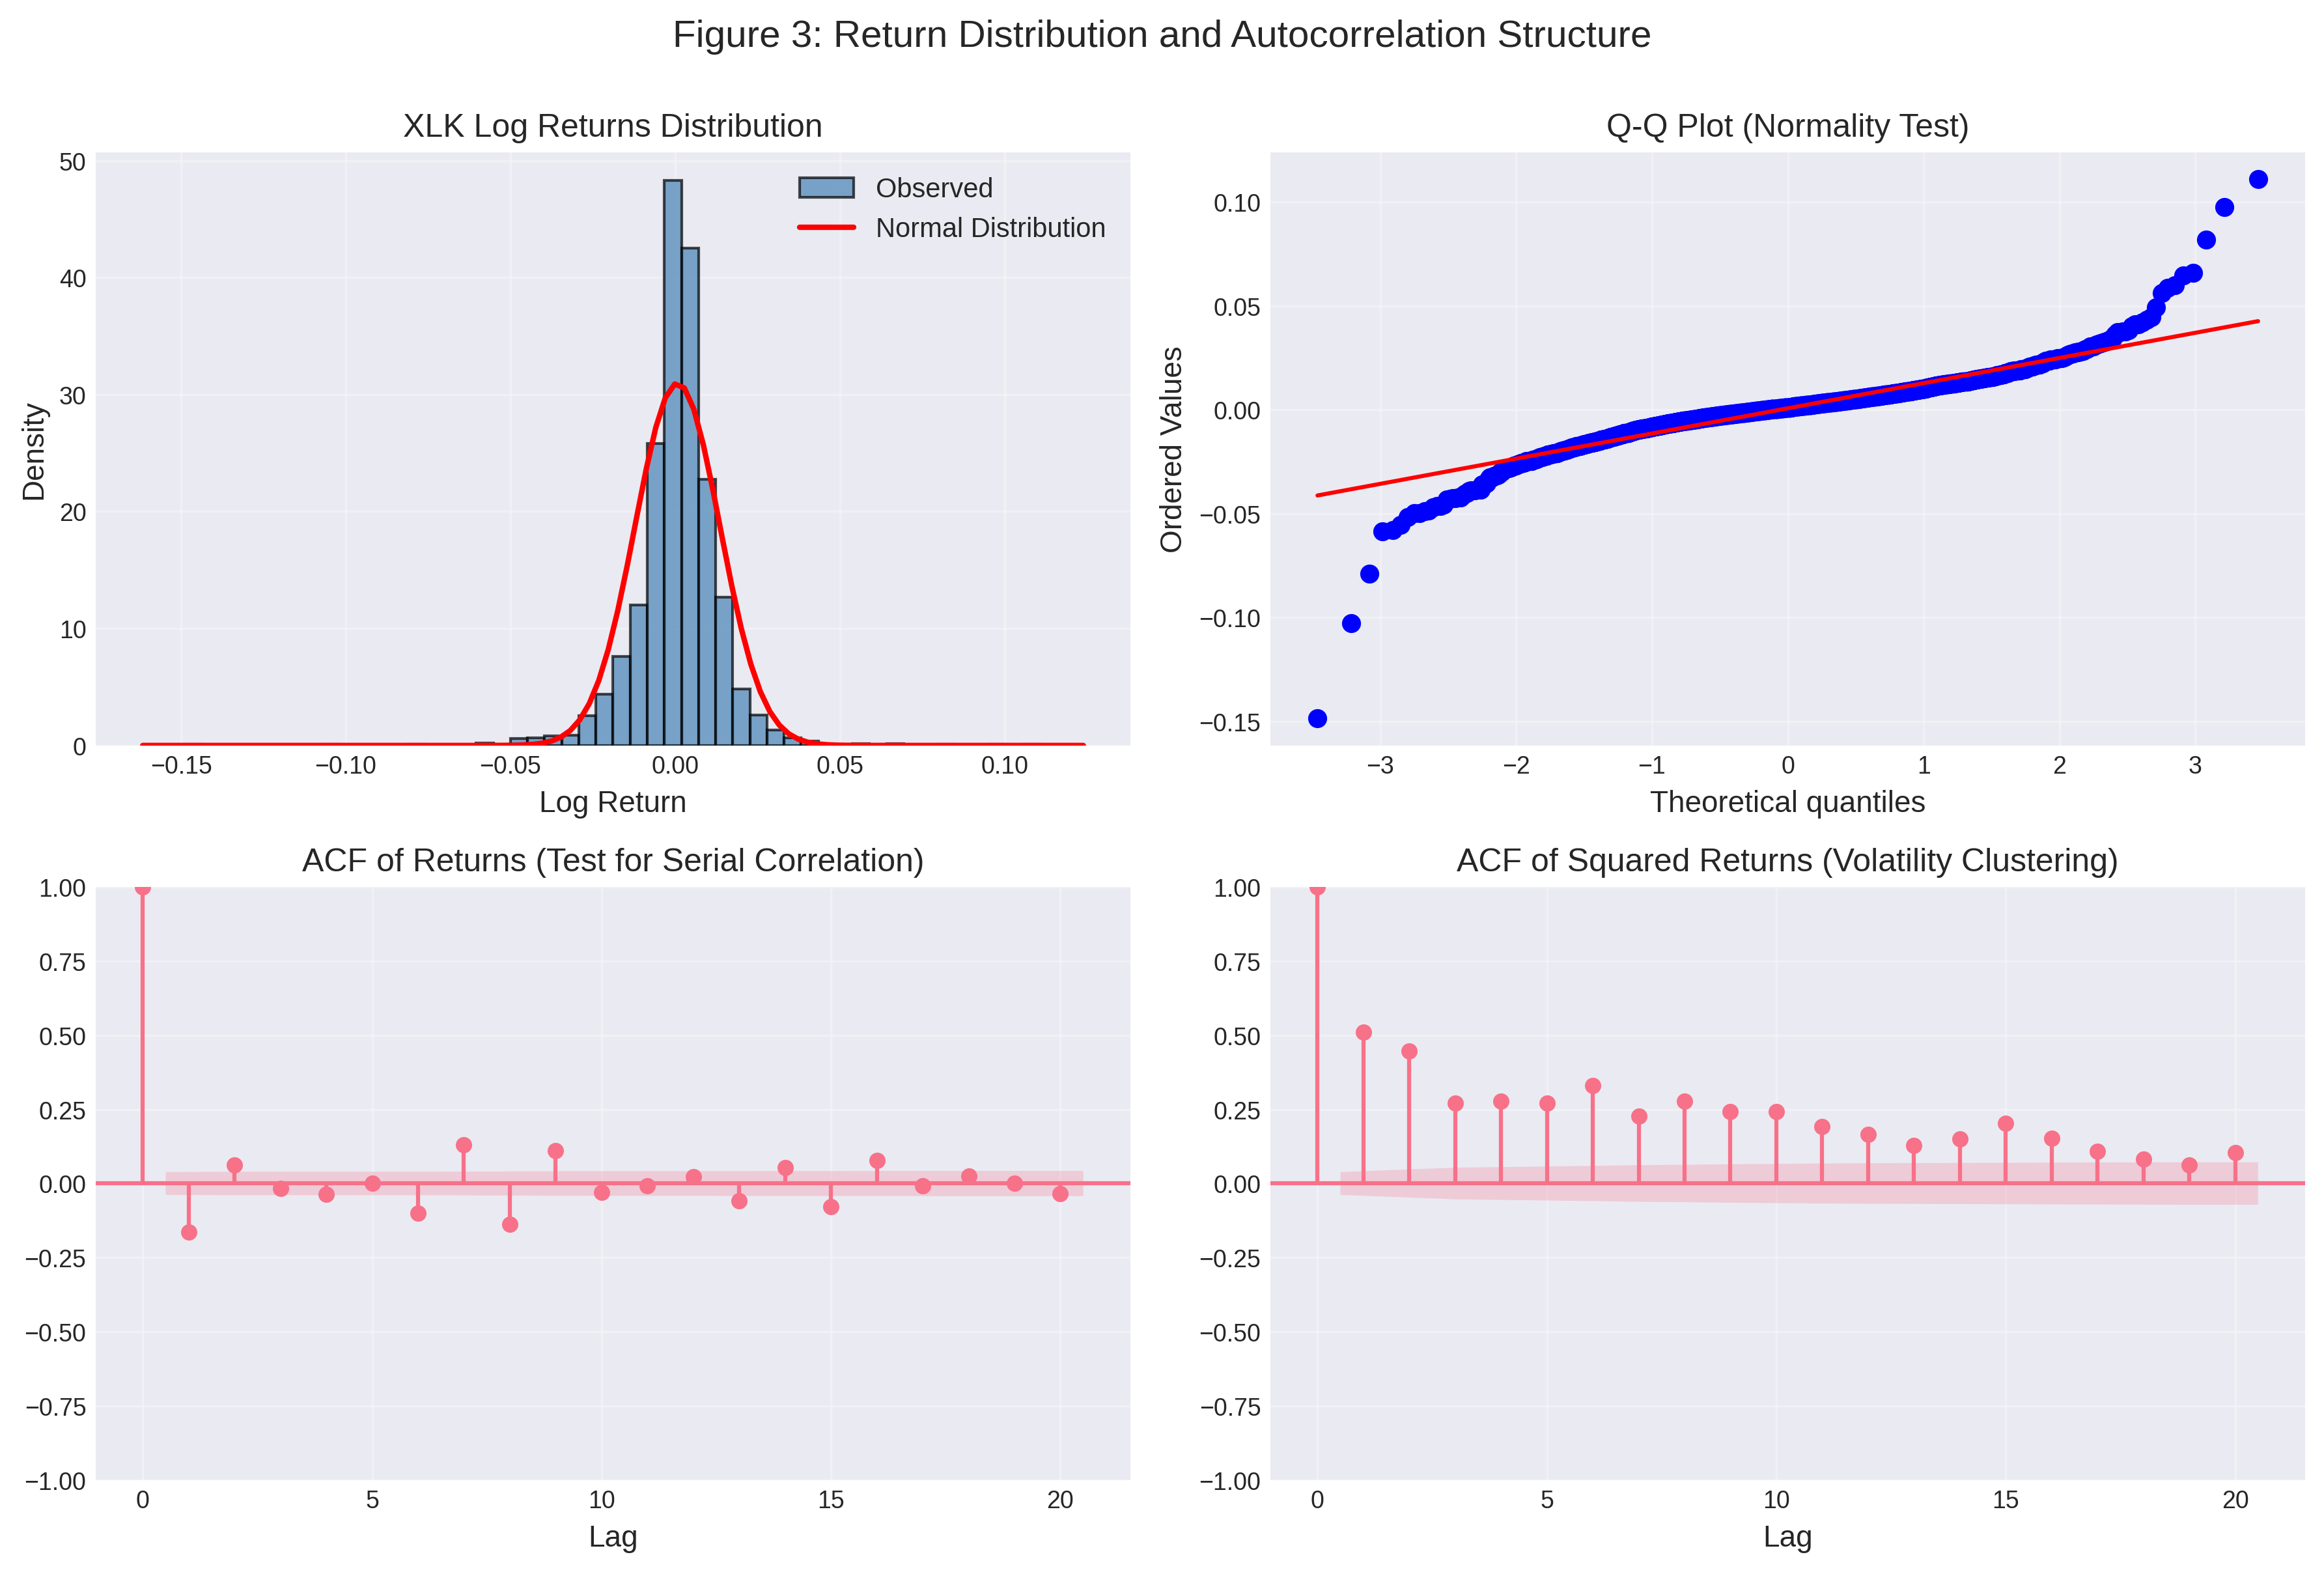

SAVED: methodology_fig3_diagnostics.png

DESCRIPTIVE STATISTICS (Training Data)
          Log_Return  VIXScaled  FearScaled   FearOrth
count      2597.0000  2597.0000   2597.0000  2597.0000
mean          0.0007     0.0000      0.0000     0.0000
std           0.0129     1.0000      1.0000     0.9127
min          -0.1487    -1.1516     -2.1536    -2.1093
25%          -0.0046    -0.6103     -0.7449    -0.7000
50%           0.0010    -0.2768     -0.1087    -0.0541
75%           0.0067     0.2686      0.7093     0.6967
max           0.1109     8.9017      2.2543     2.2096
skewness     -0.6174     2.9118      0.2142     0.1440
kurtosis     14.8845    13.9584     -0.7417    -0.7539

Interpretation:
  XLK Returns Kurtosis: 14.88 (>3 indicates fat tails)
  VIX-Fear correlation: 0.409 → -0.000


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# =============================================================================
# FIGURE 1: Time Series of All Variables (Data Coverage)
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# XLK Returns
axes[0].plot(df['Date'], df['Log_Return'], linewidth=0.5, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(train_data['Date'].iloc[-1], color='red', linestyle='--',
                label='Train/Test Split', linewidth=1.5)
axes[0].set_ylabel('XLK Log Returns')
axes[0].set_title('Figure 1: Time Series of Analysis Variables (2011-2023)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# VIX
axes[1].plot(df['Date'], df['VIXScaled'], linewidth=0.8, color='orange')
axes[1].axvline(train_data['Date'].iloc[-1], color='red', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('VIX (Scaled)')
axes[1].grid(True, alpha=0.3)

# Fear & Greed
axes[2].plot(df['Date'], df['FearScaled'], linewidth=0.8, color='purple', label='Original Fear')
axes[2].plot(df['Date'], df['FearOrth'], linewidth=0.8, color='green',
             alpha=0.7, label='Orthogonalized Fear')
axes[2].axvline(train_data['Date'].iloc[-1], color='red', linestyle='--', linewidth=1.5)
axes[2].set_ylabel('Fear Index (Scaled)')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('methodology_fig1_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print("SAVED: methodology_fig1_timeseries.png")

# =============================================================================
# FIGURE 2: Correlation Matrix (Before/After Orthogonalization)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE orthogonalization (training data only)
corr_before = train_data[['Log_Return', 'VIXScaled', 'FearScaled']].corr()
sns.heatmap(corr_before, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Correlation'}, ax=axes[0])
axes[0].set_title('Before Orthogonalization\n(Training Data)')
axes[0].set_xticklabels(['XLK Returns', 'VIX', 'Fear'], rotation=45)
axes[0].set_yticklabels(['XLK Returns', 'VIX', 'Fear'], rotation=0)

# AFTER orthogonalization
corr_after = train_data[['Log_Return', 'VIXScaled', 'FearOrth']].corr()
sns.heatmap(corr_after, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Correlation'}, ax=axes[1])
axes[1].set_title('After Orthogonalization\n(Training Data)')
axes[1].set_xticklabels(['XLK Returns', 'VIX', 'Fear Orth'], rotation=45)
axes[1].set_yticklabels(['XLK Returns', 'VIX', 'Fear Orth'], rotation=0)

plt.suptitle('Figure 2: Correlation Structure Before/After Orthogonalization',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('methodology_fig2_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("SAVED: methodology_fig2_correlations.png")

# =============================================================================
# FIGURE 3: Distribution Analysis (Justifies Student's t in GARCH)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram + Normal overlay
returns = train_data['Log_Return'].dropna()
axes[0, 0].hist(returns, bins=50, density=True, alpha=0.7, color='steelblue',
                edgecolor='black', label='Observed')

# Fit normal distribution
mu, std = returns.mean(), returns.std()
xmin, xmax = axes[0, 0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
axes[0, 0].plot(x, p, 'r-', linewidth=2, label='Normal Distribution')
axes[0, 0].set_title('XLK Log Returns Distribution')
axes[0, 0].set_xlabel('Log Return')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Q-Q Plot
stats.probplot(returns, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Test)')
axes[0, 1].grid(True, alpha=0.3)

# ACF of Returns (should be ~0)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(returns, lags=20, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF of Returns (Test for Serial Correlation)')
axes[1, 0].set_xlabel('Lag')
axes[1, 0].grid(True, alpha=0.3)

# ACF of Squared Returns (shows volatility clustering)
plot_acf(returns**2, lags=20, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF of Squared Returns (Volatility Clustering)')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Figure 3: Return Distribution and Autocorrelation Structure',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('methodology_fig3_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("SAVED: methodology_fig3_diagnostics.png")

# =============================================================================
# SUMMARY STATISTICS TABLE
# =============================================================================
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS (Training Data)")
print("="*80)

desc_stats = train_data[['Log_Return', 'VIXScaled', 'FearScaled', 'FearOrth']].describe()
desc_stats.loc['skewness'] = train_data[['Log_Return', 'VIXScaled', 'FearScaled', 'FearOrth']].skew()
desc_stats.loc['kurtosis'] = train_data[['Log_Return', 'VIXScaled', 'FearScaled', 'FearOrth']].kurtosis()

print(desc_stats.round(4))
print("\nInterpretation:")
print(f"  XLK Returns Kurtosis: {desc_stats.loc['kurtosis', 'Log_Return']:.2f} (>3 indicates fat tails)")
print(f"  VIX-Fear correlation: {corr_before.loc['VIXScaled', 'FearScaled']:.3f} → {corr_after.loc['VIXScaled', 'FearOrth']:.3f}")
print("="*80)


# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)


SECTION 3: EXPLORATORY DATA ANALYSIS

3.1 Descriptive Statistics:
  Mean:     0.000689
  Std Dev:  0.012886
  Skewness: -0.6174
  Kurtosis: 14.8844
  Min:      -0.148662
  Max:      0.110932

  Jarque-Bera test: stat=24038.30, p-value=0.00e+00

3.2 Volatility Clustering (ACF of squared returns):
  ACF lag 1: 0.5102
  ACF lag 5: 0.2716
  ACF lag 10: 0.2429

3.3 Correlation Matrix:
            Log_Return  VIXScaled  FearScaled  FearOrth
Log_Return       1.000     -0.143      -0.123    -0.070
VIXScaled       -0.143      1.000       0.409    -0.000
FearScaled      -0.123      0.409       1.000     0.913
FearOrth        -0.070     -0.000       0.913     1.000

Created results directory: results/

3.5 Correlation Heatmap:


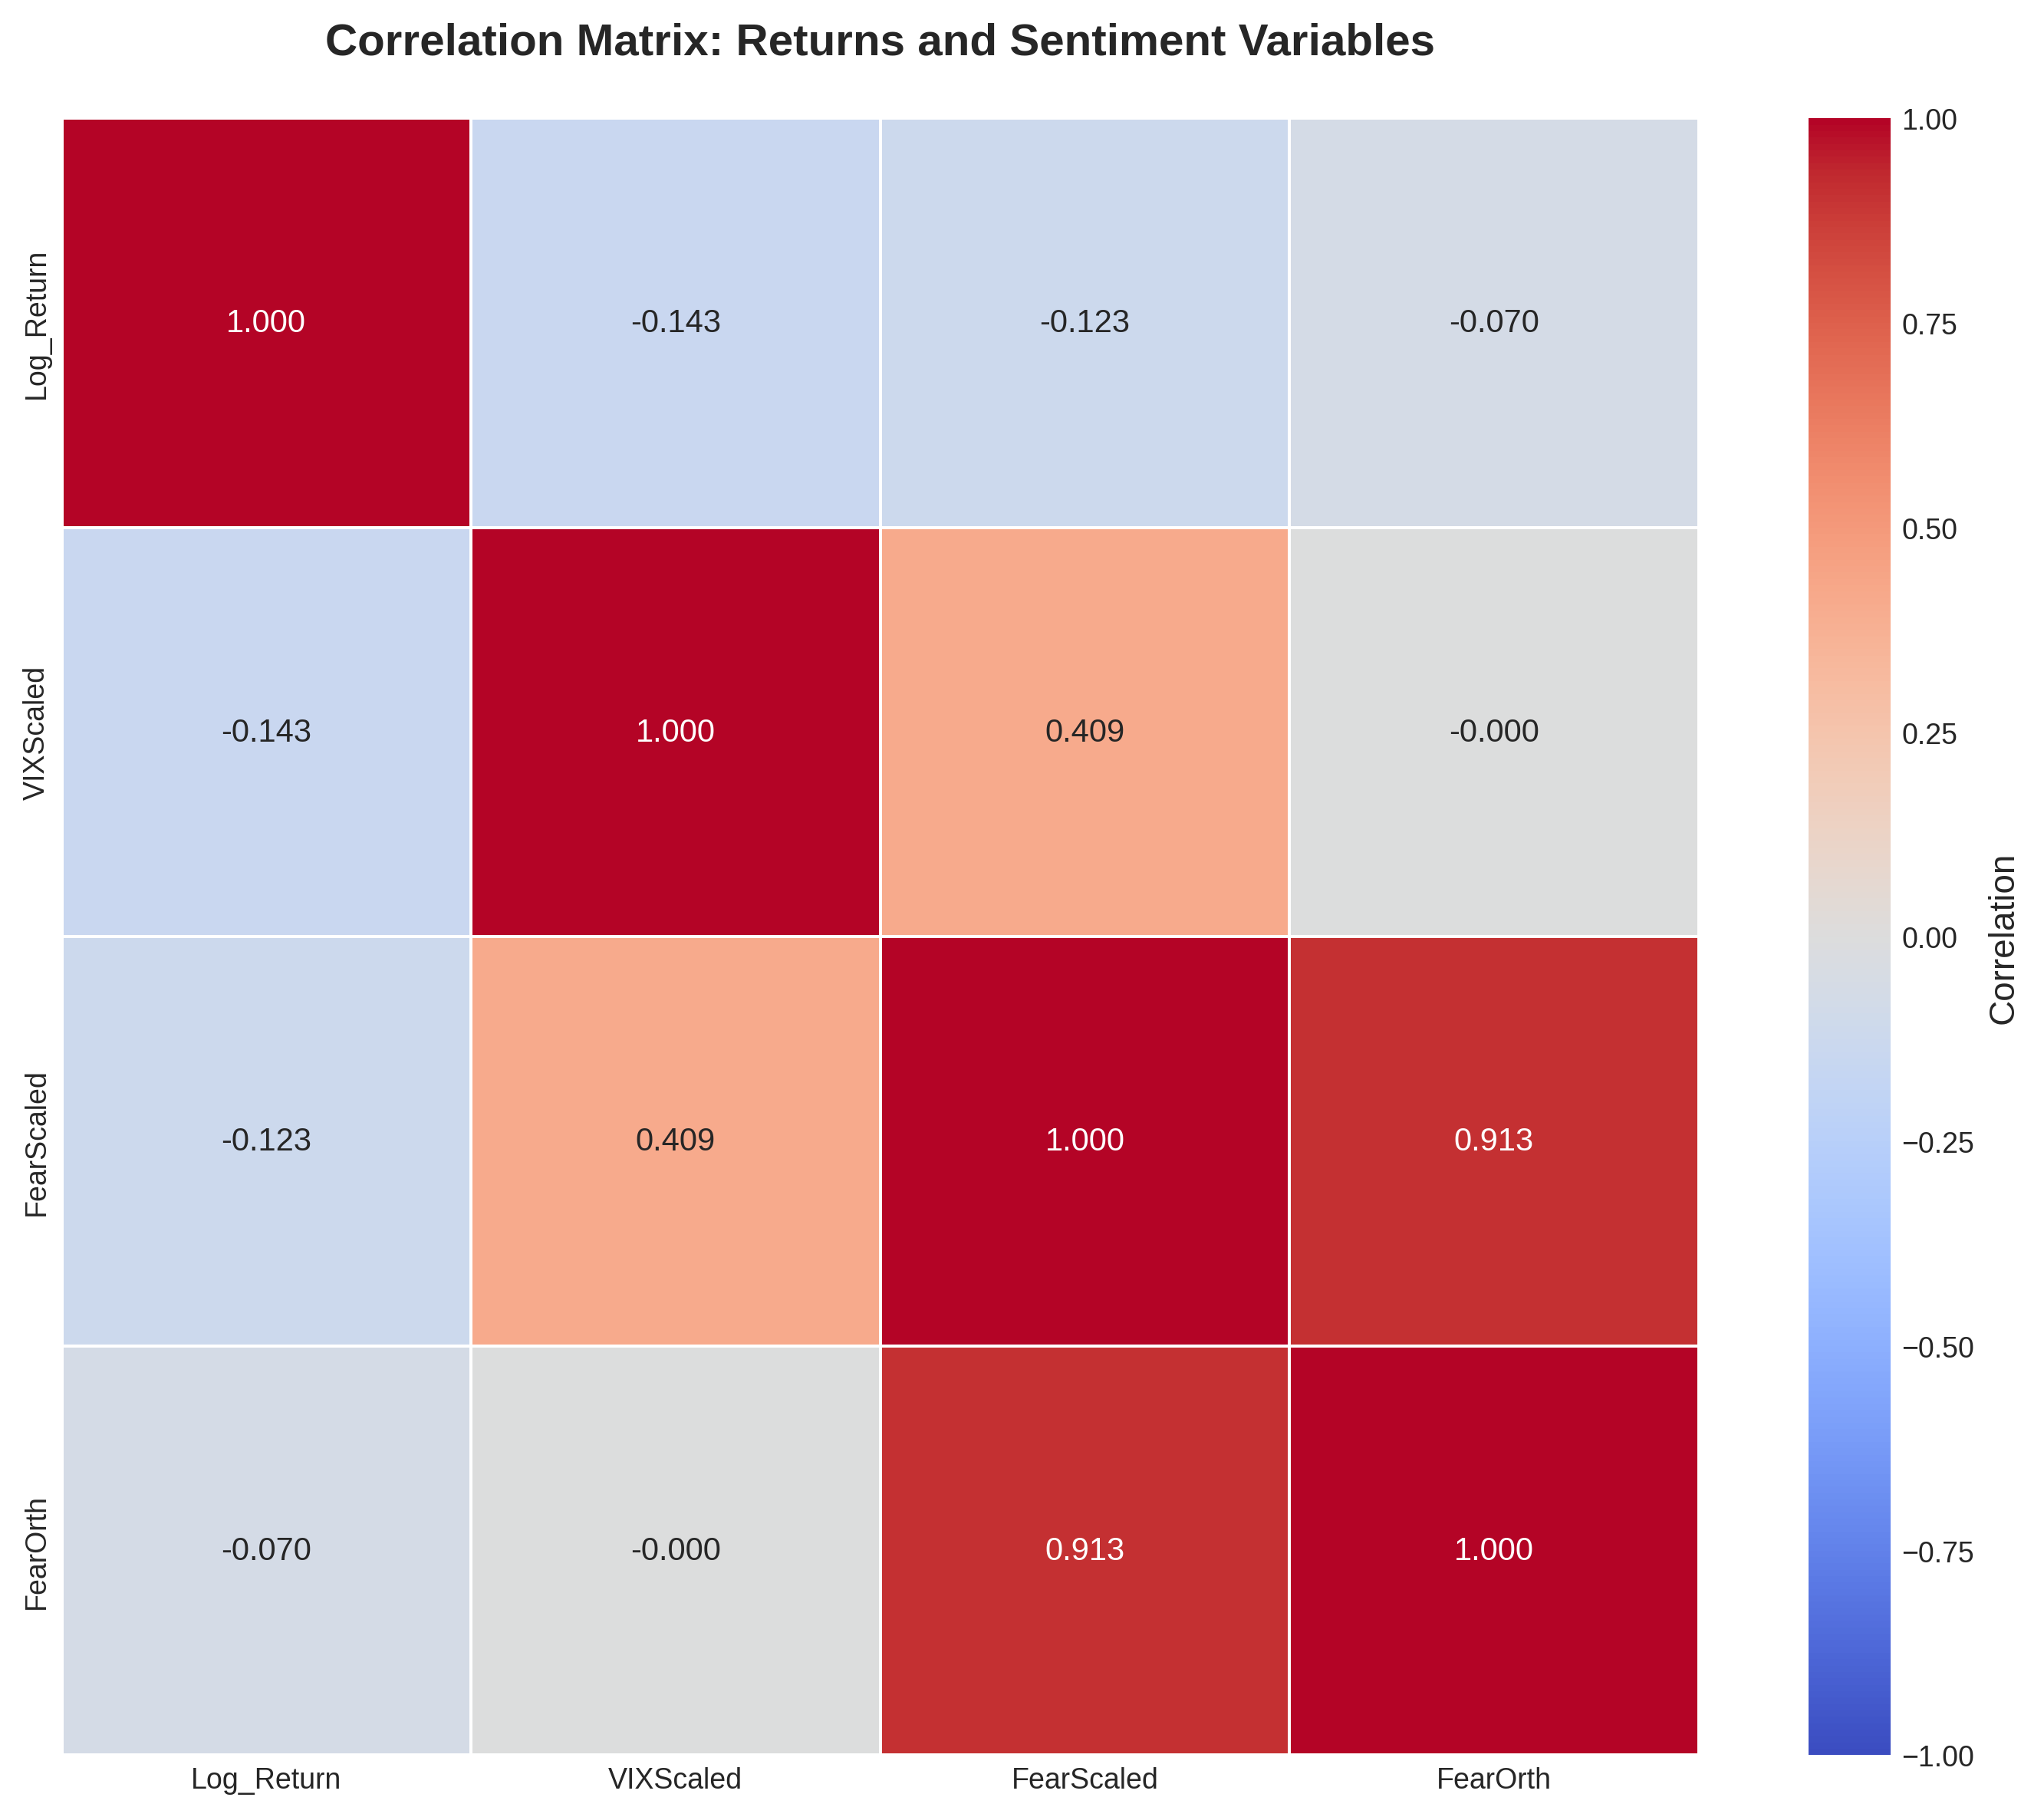

  Saved: fig4_correlation_heatmap.png

3.6 VIXScaled vs FearOrth Time Series:


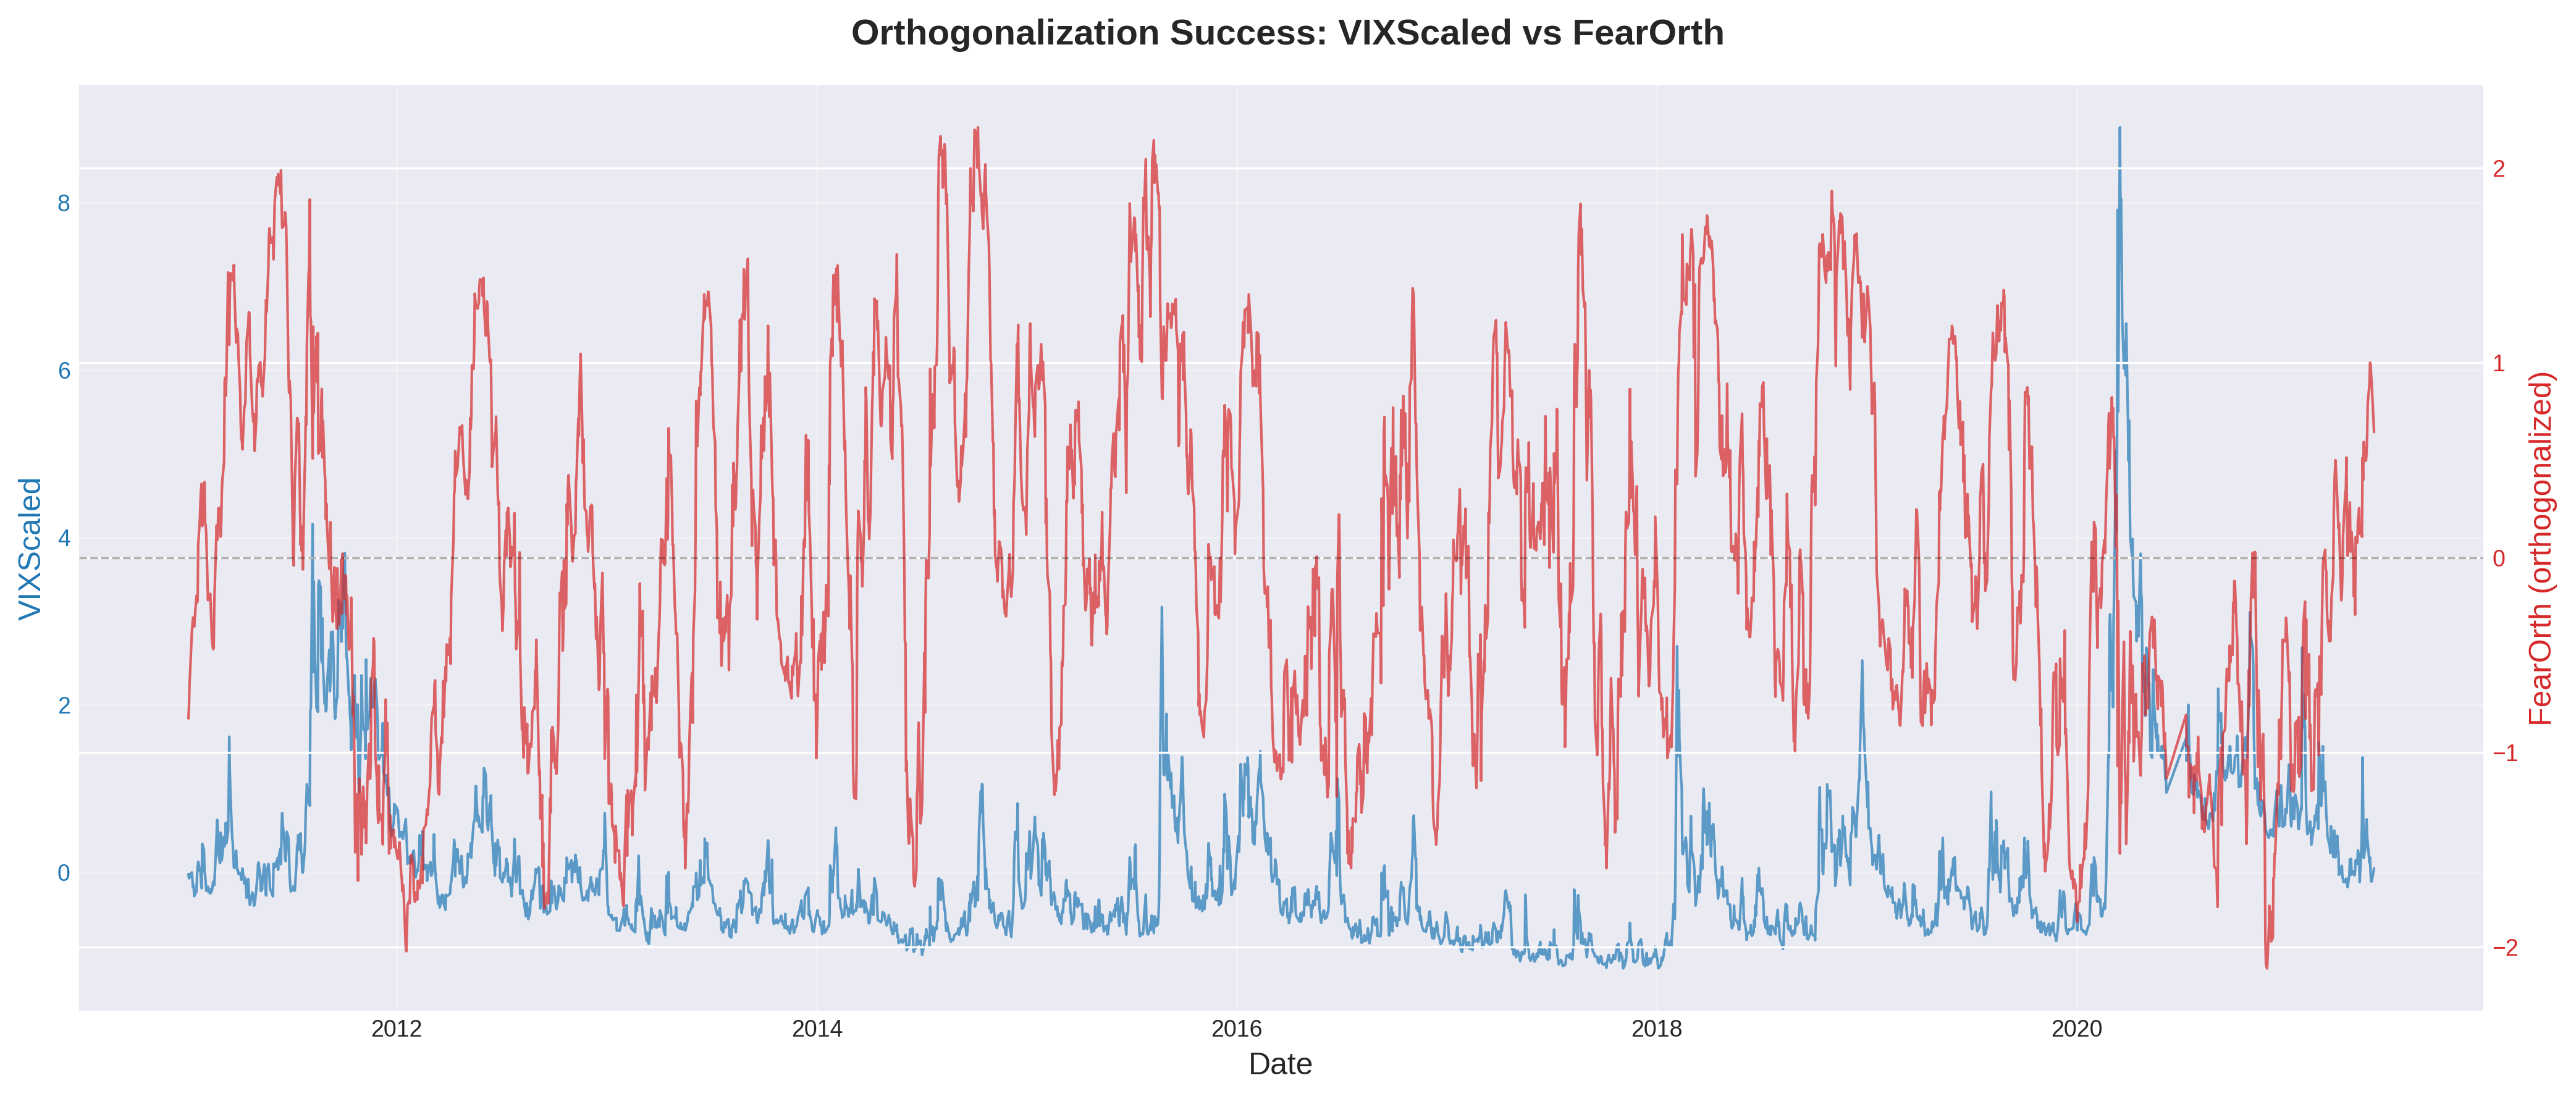

  Saved: fig5_vix_vs_fearorth.png

EDA COMPLETE


In [3]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 80)
print("SECTION 3: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Verify train_data exists from Section 2
if 'train_data' not in locals():
    df = pd.read_csv('thesis_dataset_clean.csv', parse_dates=['Date'])
    split_idx = int(len(df) * 0.8)
    train_data = df.iloc[:split_idx].copy()
    print("Reloaded train_data from CSV")

# 3.1 Descriptive Statistics
print("\n3.1 Descriptive Statistics:")
returns = train_data['Log_Return']
print(f"  Mean:     {returns.mean():.6f}")
print(f"  Std Dev:  {returns.std():.6f}")
print(f"  Skewness: {returns.skew():.4f}")
print(f"  Kurtosis: {returns.kurtosis():.4f}")
print(f"  Min:      {returns.min():.6f}")
print(f"  Max:      {returns.max():.6f}")

# Jarque-Bera test
jb_stat, jb_pval = stats.jarque_bera(returns.dropna())
print(f"\n  Jarque-Bera test: stat={jb_stat:.2f}, p-value={jb_pval:.2e}")

# 3.2 Volatility Clustering
print("\n3.2 Volatility Clustering (ACF of squared returns):")
from statsmodels.tsa.stattools import acf
squared_returns = returns ** 2
acf_values = acf(squared_returns.dropna(), nlags=20)
print(f"  ACF lag 1: {acf_values[1]:.4f}")
print(f"  ACF lag 5: {acf_values[5]:.4f}")
print(f"  ACF lag 10: {acf_values[10]:.4f}")

# 3.3 Correlation Matrix
print("\n3.3 Correlation Matrix:")
corr_vars = ['Log_Return', 'VIXScaled', 'FearScaled', 'FearOrth']
corr_matrix = train_data[corr_vars].corr()
print(corr_matrix.round(3))

# 3.4 Create results directory
results_dir = 'results'
os.makedirs(results_dir, exist_ok=True)
print(f"\nCreated results directory: {results_dir}/")

# 3.5 Correlation Heatmap
print("\n3.5 Correlation Heatmap:")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=ax, vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'},
            square=True, linewidths=0.5)
ax.set_title('Correlation Matrix: Returns and Sentiment Variables',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{results_dir}/fig4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"  Saved: fig4_correlation_heatmap.png")

# 3.6 VIXScaled vs FearOrth Time Series
print("\n3.6 VIXScaled vs FearOrth Time Series:")
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('VIXScaled', color=color1, fontsize=12)
ax1.plot(train_data['Date'], train_data['VIXScaled'], color=color1,
         label='VIXScaled', alpha=0.7, linewidth=1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('FearOrth (orthogonalized)', color=color2, fontsize=12)
ax2.plot(train_data['Date'], train_data['FearOrth'], color=color2,
         label='FearOrth', alpha=0.7, linewidth=1)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)

fig.suptitle('Orthogonalization Success: VIXScaled vs FearOrth',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(f'{results_dir}/fig5_vix_vs_fearorth.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"  Saved: fig5_vix_vs_fearorth.png")

print("\n" + "=" * 80)
print("EDA COMPLETE")
print("=" * 80)


# SECTION 4: Baseline GARCH


SECTION 4: BASELINE GARCH MODELS

Training data prepared:
  Observations: 2597
  Mean: 0.0689%
  Std: 1.2886%
  Date range: 2011-01-04 to 2021-06-01

--------------------------------------------------------------------------------
STEP 1: MODEL SELECTION (Grid Search)
--------------------------------------------------------------------------------

Top 10 Models by BIC:
 AR  GARCH_p  GARCH_q  Log-Likelihood         AIC         BIC
  0        1        1    -3643.114858 7298.229715 7333.402389
  1        1        1    -3639.766408 7293.532817 7334.564906
  2        1        1    -3638.906721 7293.813442 7340.704177
  0        2        1    -3643.032434 7300.064869 7341.099654
  0        1        2    -3643.114858 7300.229716 7341.264502
  1        2        1    -3639.571619 7295.143238 7342.037055
  1        1        2    -3639.766408 7295.532817 7342.426634
  2        2        1    -3638.730148 7295.460295 7348.212371
  0        3        1    -3642.698726 7301.397451 7348.294349
  2   

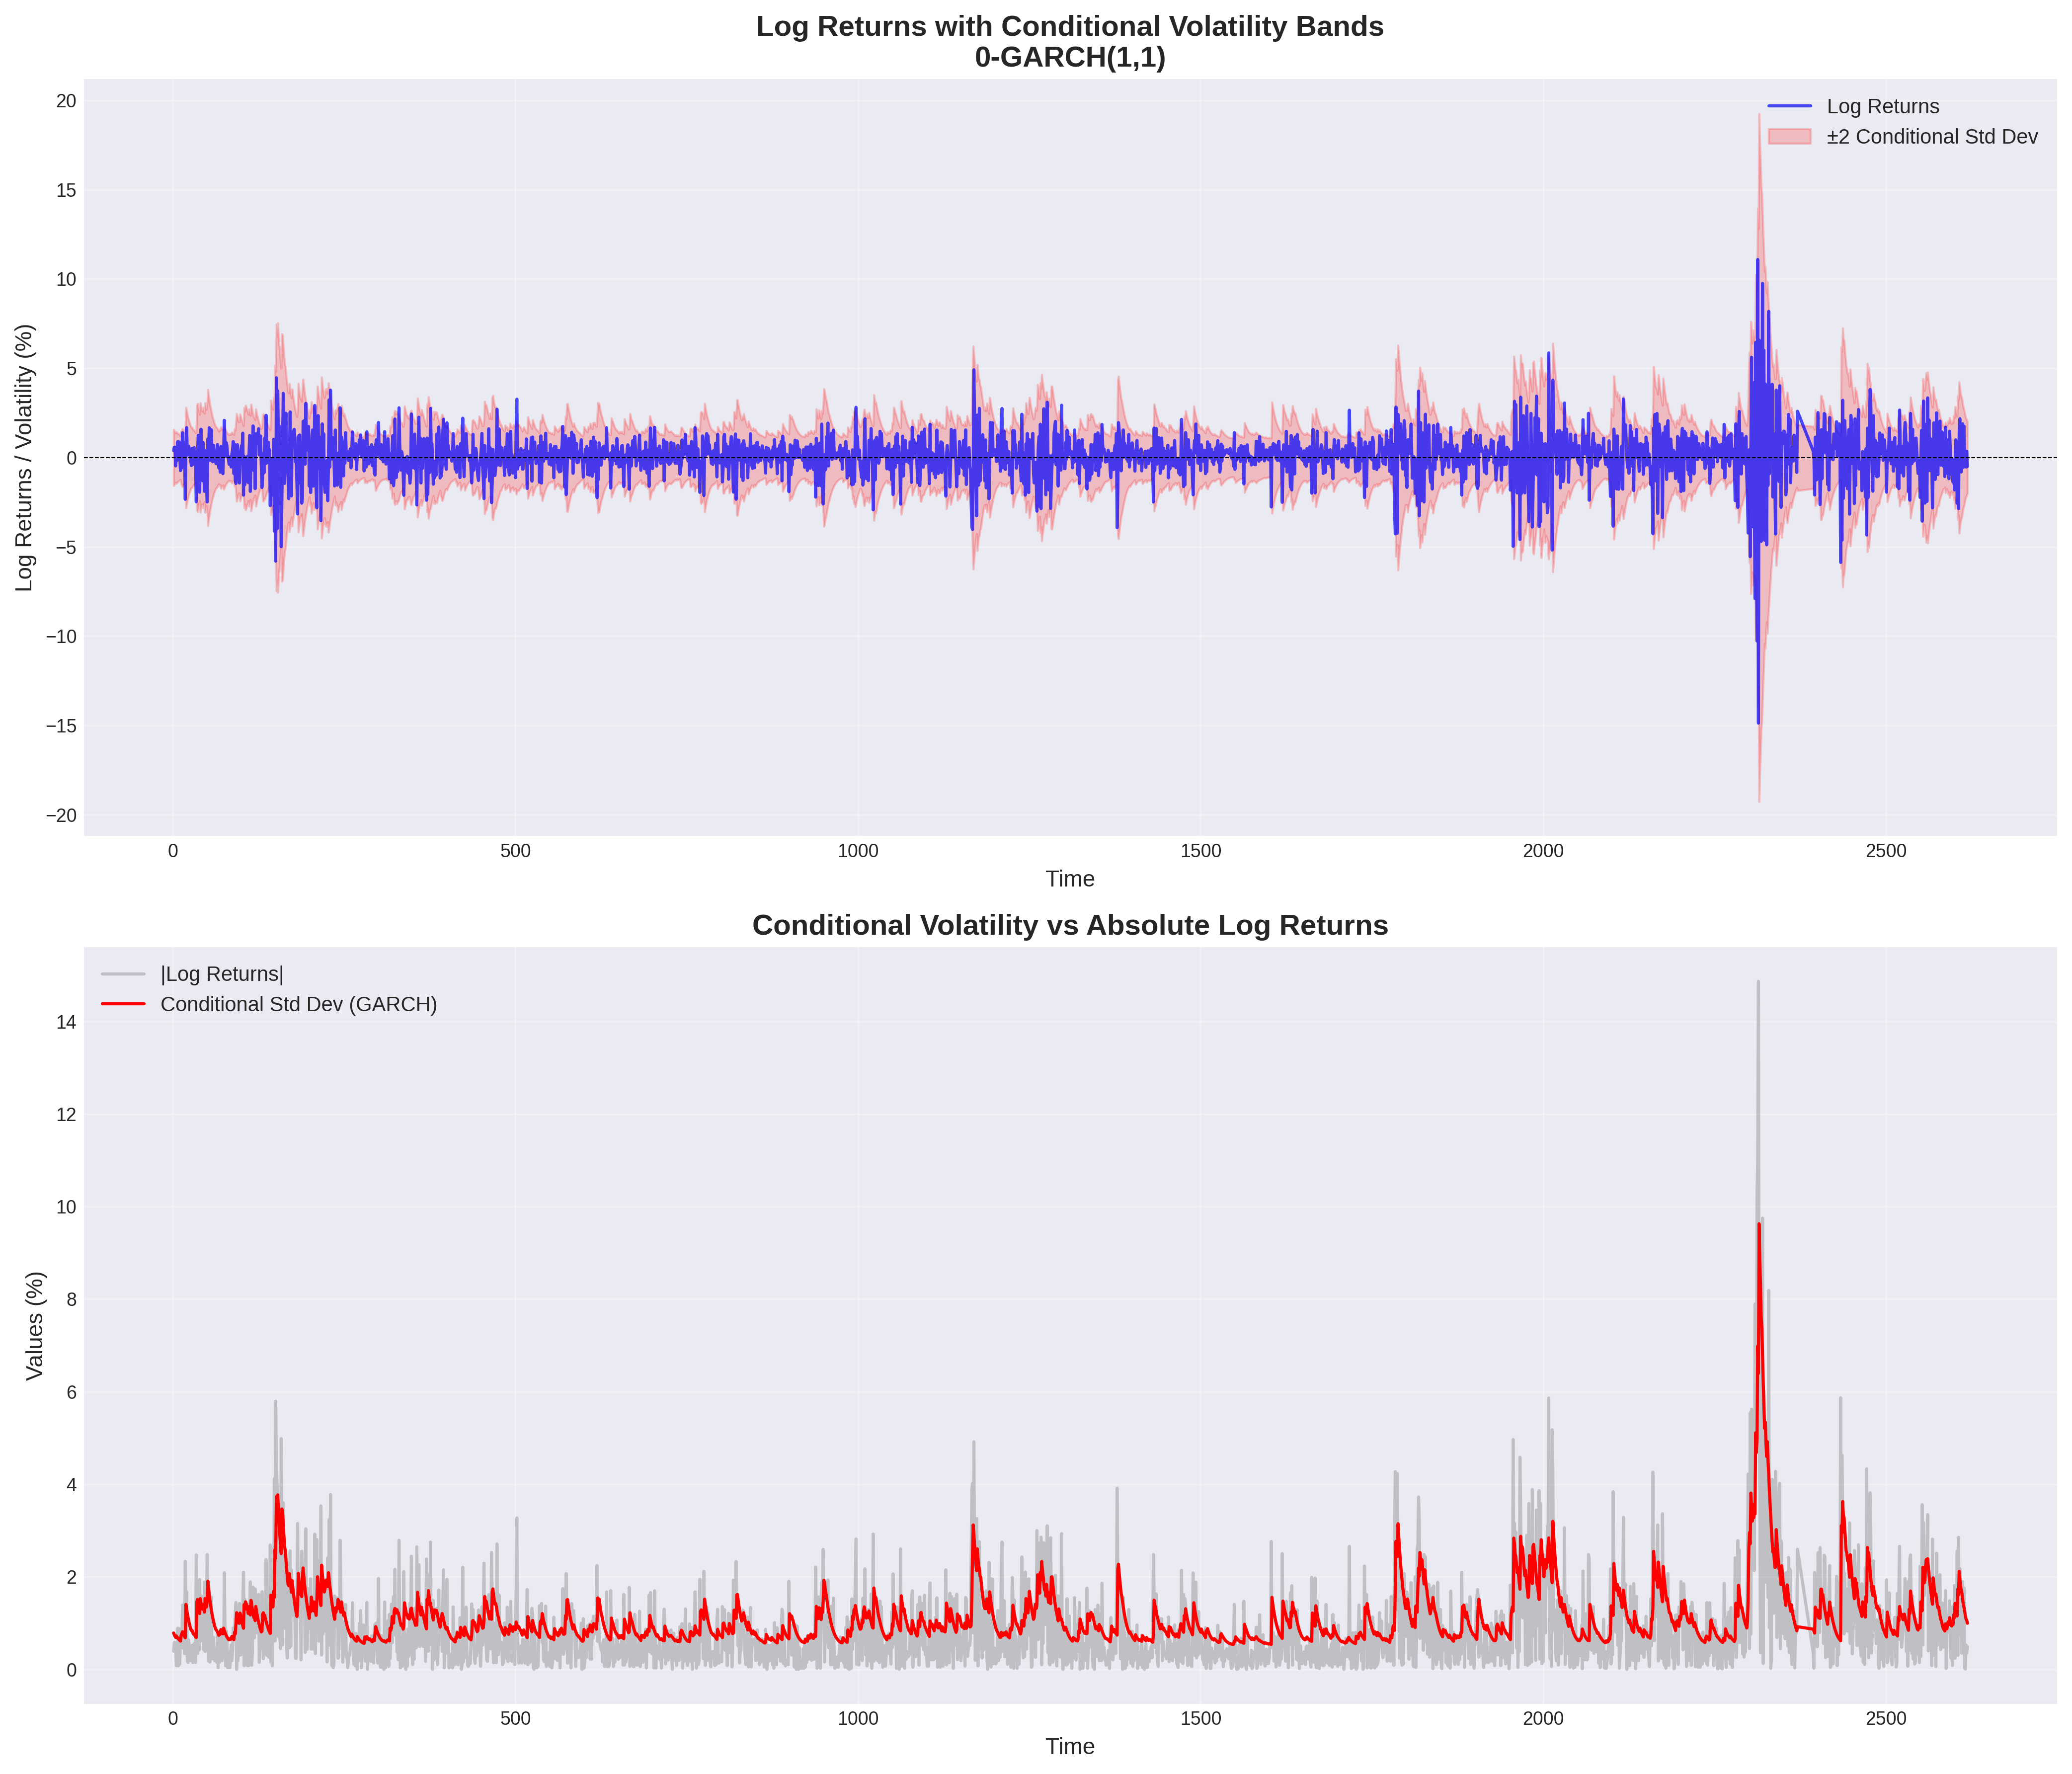

  Saved: fig9_combined_garch_plots.png

MODEL COMPARISON SUMMARY

          Model  Log-Likelihood         AIC         BIC  Num Parameters
    GARCH(1,1)    -3682.509245 7375.018489 7404.329050               5
GJR-GARCH(1,1)    -3643.114858 7298.229715 7333.402389               6

Best model by AIC: GJR-GARCH(1,1)
Best model by BIC: GJR-GARCH(1,1)

Saved: baseline_model_comparison.csv

BASELINE GARCH MODELS COMPLETE


In [4]:
try:
    import arch
except ImportError:
    import subprocess
    import sys
    print("Installing arch library (one-time setup)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "arch"])
    import arch

from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 80)
print("SECTION 4: BASELINE GARCH MODELS")
print("=" * 80)

# Prepare training data (arch library expects percentage returns)
returns_train = train_data['Log_Return'].dropna() * 100

print(f"\nTraining data prepared:")
print(f"  Observations: {len(returns_train)}")
print(f"  Mean: {returns_train.mean():.4f}%")
print(f"  Std: {returns_train.std():.4f}%")
print(f"  Date range: {train_data['Date'].iloc[0].date()} to {train_data['Date'].iloc[-1].date()}")

# =============================================================================
# STEP 1: MODEL SELECTION
# =============================================================================
print("\n" + "-" * 80)
print("STEP 1: MODEL SELECTION (Grid Search)")
print("-" * 80)

# Initialize variables for tracking the best model
best_model = None
best_bic = np.inf
best_order = (0, 0, 0)  # (AR order, GARCH p, GARCH q)

# Search over combinations of AR(p), GARCH(p,q) parameters
comparison_results = []

for p in range(3):  # AR order (0, 1, 2)
    for garch_p in range(1, 4):  # GARCH p (1, 2, 3)
        for garch_q in range(0, 4):  # GARCH q (0, 1, 2, 3)
            try:
                # Fit AR(p)-GARCH(garch_p, garch_q) model with Student's t
                model = arch_model(
                    returns_train,
                    mean='AR',
                    lags=p,
                    vol='GARCH',
                    p=garch_p,
                    q=garch_q,
                    dist='t',   # Student's t distribution (better for fat tails)
                    o = 1       # adds the GJR asymmetry term
                )
                result = model.fit(disp='off')

                # Track results
                comparison_results.append({
                    'AR': p,
                    'GARCH_p': garch_p,
                    'GARCH_q': garch_q,
                    'Log-Likelihood': result.loglikelihood,
                    'AIC': result.aic,
                    'BIC': result.bic
                })

                # Track the best model based on BIC
                if result.bic < best_bic:
                    best_bic = result.bic
                    best_model = result
                    best_order = (p, garch_p, garch_q)

            except Exception as e:
                print(f"  Error with AR({p})-GARCH({garch_p},{garch_q}): {e}")

# Display results
comparison_df = pd.DataFrame(comparison_results).sort_values('BIC').head(10)
print("\nTop 10 Models by BIC:")
print(comparison_df.to_string(index=False))

print(f"\n{'='*80}")
print(f"BEST MODEL: AR({best_order[0]})-GJR-GARCH({best_order[1]},{best_order[2]})")
print(f"BIC: {best_bic:.2f}")
print(f"{'='*80}\n")

# Save comparison
comparison_df.to_csv(f'{results_dir}/model_selection_grid_search.csv', index=False)
print(f"Saved: model_selection_grid_search.csv")

# =============================================================================
# STEP 2: ESTIMATE ALL BASELINE MODELS
# =============================================================================
baseline_results = {}

# Model 1: GARCH(1,1) with Student's t
print("\n" + "-" * 80)
print("MODEL 1: GARCH(1,1) with Student's t")
print("-" * 80)

try:
    model_garch11 = arch_model(
        returns_train,
        mean='AR',
        lags=0,
        vol='GARCH',
        p=1,
        q=1,
        dist='t'
    )
    result_garch11 = model_garch11.fit(disp='off')
    baseline_results['GARCH(1,1)'] = result_garch11

    print("\nParameter Estimates:")
    print(result_garch11.params)

    print("\nModel Fit:")
    print(f"  Log-Likelihood: {result_garch11.loglikelihood:.2f}")
    print(f"  AIC: {result_garch11.aic:.2f}")
    print(f"  BIC: {result_garch11.bic:.2f}")

    print("\nGARCH(1,1) estimation SUCCESSFUL")

except Exception as e:
    print(f"\nERROR: GARCH(1,1) failed: {e}")
    baseline_results['GARCH(1,1)'] = None

# Model 2: GJR-GARCH(1,1) with Student's t
print("\n" + "-" * 80)
print("MODEL 2: GJR-GARCH(1,1) with Student's t")
print("-" * 80)

try:
    model_gjr = arch_model(
        returns_train,
        mean='AR',
        lags=0,
        vol='GARCH',
        p=1,
        o=1,  # Asymmetry parameter
        q=1,
        dist='t'
    )
    result_gjr = model_gjr.fit(disp='off')
    baseline_results['GJR-GARCH(1,1)'] = result_gjr

    print("\nParameter Estimates:")
    print(result_gjr.params)

    print("\nAsymmetry Interpretation:")
    gamma = result_gjr.params['gamma[1]']
    if gamma > 0:
        print(f"  Gamma = {gamma:.4f} > 0: Negative shocks increase volatility MORE")
        print(f"  This is the 'leverage effect' (typical for stocks)")

    print("\nModel Fit:")
    print(f"  Log-Likelihood: {result_gjr.loglikelihood:.2f}")
    print(f"  AIC: {result_gjr.aic:.2f}")
    print(f"  BIC: {result_gjr.bic:.2f}")

    print("\nGJR-GARCH(1,1) estimation SUCCESSFUL")

except Exception as e:
    print(f"\nERROR: GJR-GARCH(1,1) failed: {e}")
    baseline_results['GJR-GARCH(1,1)'] = None

# =============================================================================
# STEP 3: VISUALIZATIONS
# =============================================================================
print("\n" + "-" * 80)
print("STEP 3: CREATING VISUALIZATIONS")
print("-" * 80)

# Use the best model for visualization
if best_model is not None:
    # Get conditional volatility and standardized residuals
    conditional_volatility = best_model.conditional_volatility
    absolute_log_returns = np.abs(returns_train)

    # Create figure with two subplots
    fig, axs = plt.subplots(2, 1, figsize=(14, 12))

    # Plot 1: Log returns with shaded ±2 conditional standard deviations
    axs[0].plot(returns_train, label='Log Returns', color='blue', alpha=0.7)
    upper_bound = 2 * conditional_volatility
    lower_bound = -2 * conditional_volatility
    axs[0].fill_between(
        returns_train.index,
        lower_bound,
        upper_bound,
        color='red',
        alpha=0.2,
        label='±2 Conditional Std Dev'
    )
    axs[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
    axs[0].set_title(f'Log Returns with Conditional Volatility Bands\n{best_order[0]}-GARCH({best_order[1]},{best_order[2]})',
                     fontsize=14, fontweight='bold')
    axs[0].set_xlabel('Time')
    axs[0].set_ylabel('Log Returns / Volatility (%)')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Plot 2: Conditional Std Dev vs. Absolute Log Returns
    axs[1].plot(absolute_log_returns, label='|Log Returns|', color='gray', alpha=0.4)
    axs[1].plot(conditional_volatility, label='Conditional Std Dev (GARCH)', color='red', linewidth=1.5)
    axs[1].set_title('Conditional Volatility vs Absolute Log Returns', fontsize=14, fontweight='bold')
    axs[1].set_xlabel('Time')
    axs[1].set_ylabel('Values (%)')
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{results_dir}/fig9_combined_garch_plots.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  Saved: fig9_combined_garch_plots.png")

# =============================================================================
# STEP 4: MODEL COMPARISON TABLE
# =============================================================================
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

comparison_data = []
for model_name, result in baseline_results.items():
    if result is not None:
        comparison_data.append({
            'Model': model_name,
            'Log-Likelihood': result.loglikelihood,
            'AIC': result.aic,
            'BIC': result.bic,
            'Num Parameters': len(result.params)
        })

if comparison_data:
    final_comparison_df = pd.DataFrame(comparison_data)
    print("\n", final_comparison_df.to_string(index=False))

    # Best model by AIC/BIC
    best_aic = final_comparison_df.loc[final_comparison_df['AIC'].idxmin(), 'Model']
    best_bic = final_comparison_df.loc[final_comparison_df['BIC'].idxmin(), 'Model']

    print(f"\nBest model by AIC: {best_aic}")
    print(f"Best model by BIC: {best_bic}")

    # Save comparison
    final_comparison_df.to_csv(f'{results_dir}/baseline_model_comparison.csv', index=False)
    print(f"\nSaved: baseline_model_comparison.csv")

print("\n" + "=" * 80)
print("BASELINE GARCH MODELS COMPLETE")
print("=" * 80)


# Section 5: Create Returns for all series

In [7]:
# =============================================================================
# SECTION 5: CREATE RETURNS FOR ALL SERIES (Log Returns for Consistency)
# =============================================================================
print("\n" + "=" * 80)
print("SECTION 5: CREATING RETURNS FOR ALL SERIES")
print("=" * 80)

# Use log returns for VIX and Fear (consistent with XLK methodology)
# NOTE: Computing on ORIGINAL values (VIX, FearIndex), not scaled versions
train_data['VIX_Return'] = np.log(train_data['VIX'] / train_data['VIX'].shift(1)) * 100
train_data['FEAR_Return'] = np.log(train_data['FearIndex'] / train_data['FearIndex'].shift(1)) * 100

# For orthogonal Fear: compute return on the orthogonalized scaled series
# (since FearOrth can be negative, use first differences instead of log)
train_data['FEAR_Orthogonal_Return'] = train_data['FearOrth'].diff() * 100

# Already have XLK log returns
train_data['SP500_Tech_Return'] = train_data['Log_Return'] * 100

# Drop NaNs created by lag operations
train_data_clean = train_data.dropna()

print(f"Final train_data shape: {train_data_clean.shape}")
print(f"Date range: {train_data_clean['Date'].iloc[0].date()} to {train_data_clean['Date'].iloc[-1].date()}")

# Verify returns look reasonable
print("\nReturns Summary (% units for GARCH input):")
for col in ['SP500_Tech_Return', 'VIX_Return', 'FEAR_Return', 'FEAR_Orthogonal_Return']:
    data = train_data_clean[col]
    print(f"  {col:30s}: N={len(data):4d}, Mean={data.mean():7.3f}%, Std={data.std():7.2f}%")

print("\n" + "=" * 80)
print("RETURNS CREATED - Ready for univariate GARCH on each series")
print("=" * 80)



SECTION 5: CREATING RETURNS FOR ALL SERIES
Final train_data shape: (2596, 13)
Date range: 2011-01-05 to 2021-06-01

Returns Summary (% units for GARCH input):
  SP500_Tech_Return             : N=2596, Mean=  0.069%, Std=   1.29%
  VIX_Return                    : N=2596, Mean=  0.001%, Std=   7.96%
  FEAR_Return                   : N=2596, Mean=  0.027%, Std=  13.78%
  FEAR_Orthogonal_Return        : N=2596, Mean=  0.057%, Std=  20.74%

RETURNS CREATED - Ready for univariate GARCH on each series


#Section 6: Univariate Garch + Resid. Correlations


SECTION 6: UNIVARIATE GARCH MODELS + RESIDUAL CORRELATIONS

--------------------------------------------------------------------------------
STEP 1: FIT GJR-GARCH(1,1) TO EACH TIME SERIES
--------------------------------------------------------------------------------

FITTING GJR-GARCH(1,1) TO: SP500_Tech

ERROR fitting SP500_Tech: name 'train_data_clean' is not defined

FITTING GJR-GARCH(1,1) TO: VIX

ERROR fitting VIX: name 'train_data_clean' is not defined

FITTING GJR-GARCH(1,1) TO: FEAR

ERROR fitting FEAR: name 'train_data_clean' is not defined

FITTING GJR-GARCH(1,1) TO: FEAR_Orthogonal

ERROR fitting FEAR_Orthogonal: name 'train_data_clean' is not defined

STEP 2: MODEL COMPARISON ACROSS ALL SERIES

 Empty DataFrame
Columns: []
Index: []

Saved: univariate_garch_comparison.csv

STEP 3: STANDARDIZED RESIDUALS CORRELATION ANALYSIS

Standardized residuals shape: (0, 0)
Observations: 0

--------------------------------------------------------------------------------
CORRELATION M

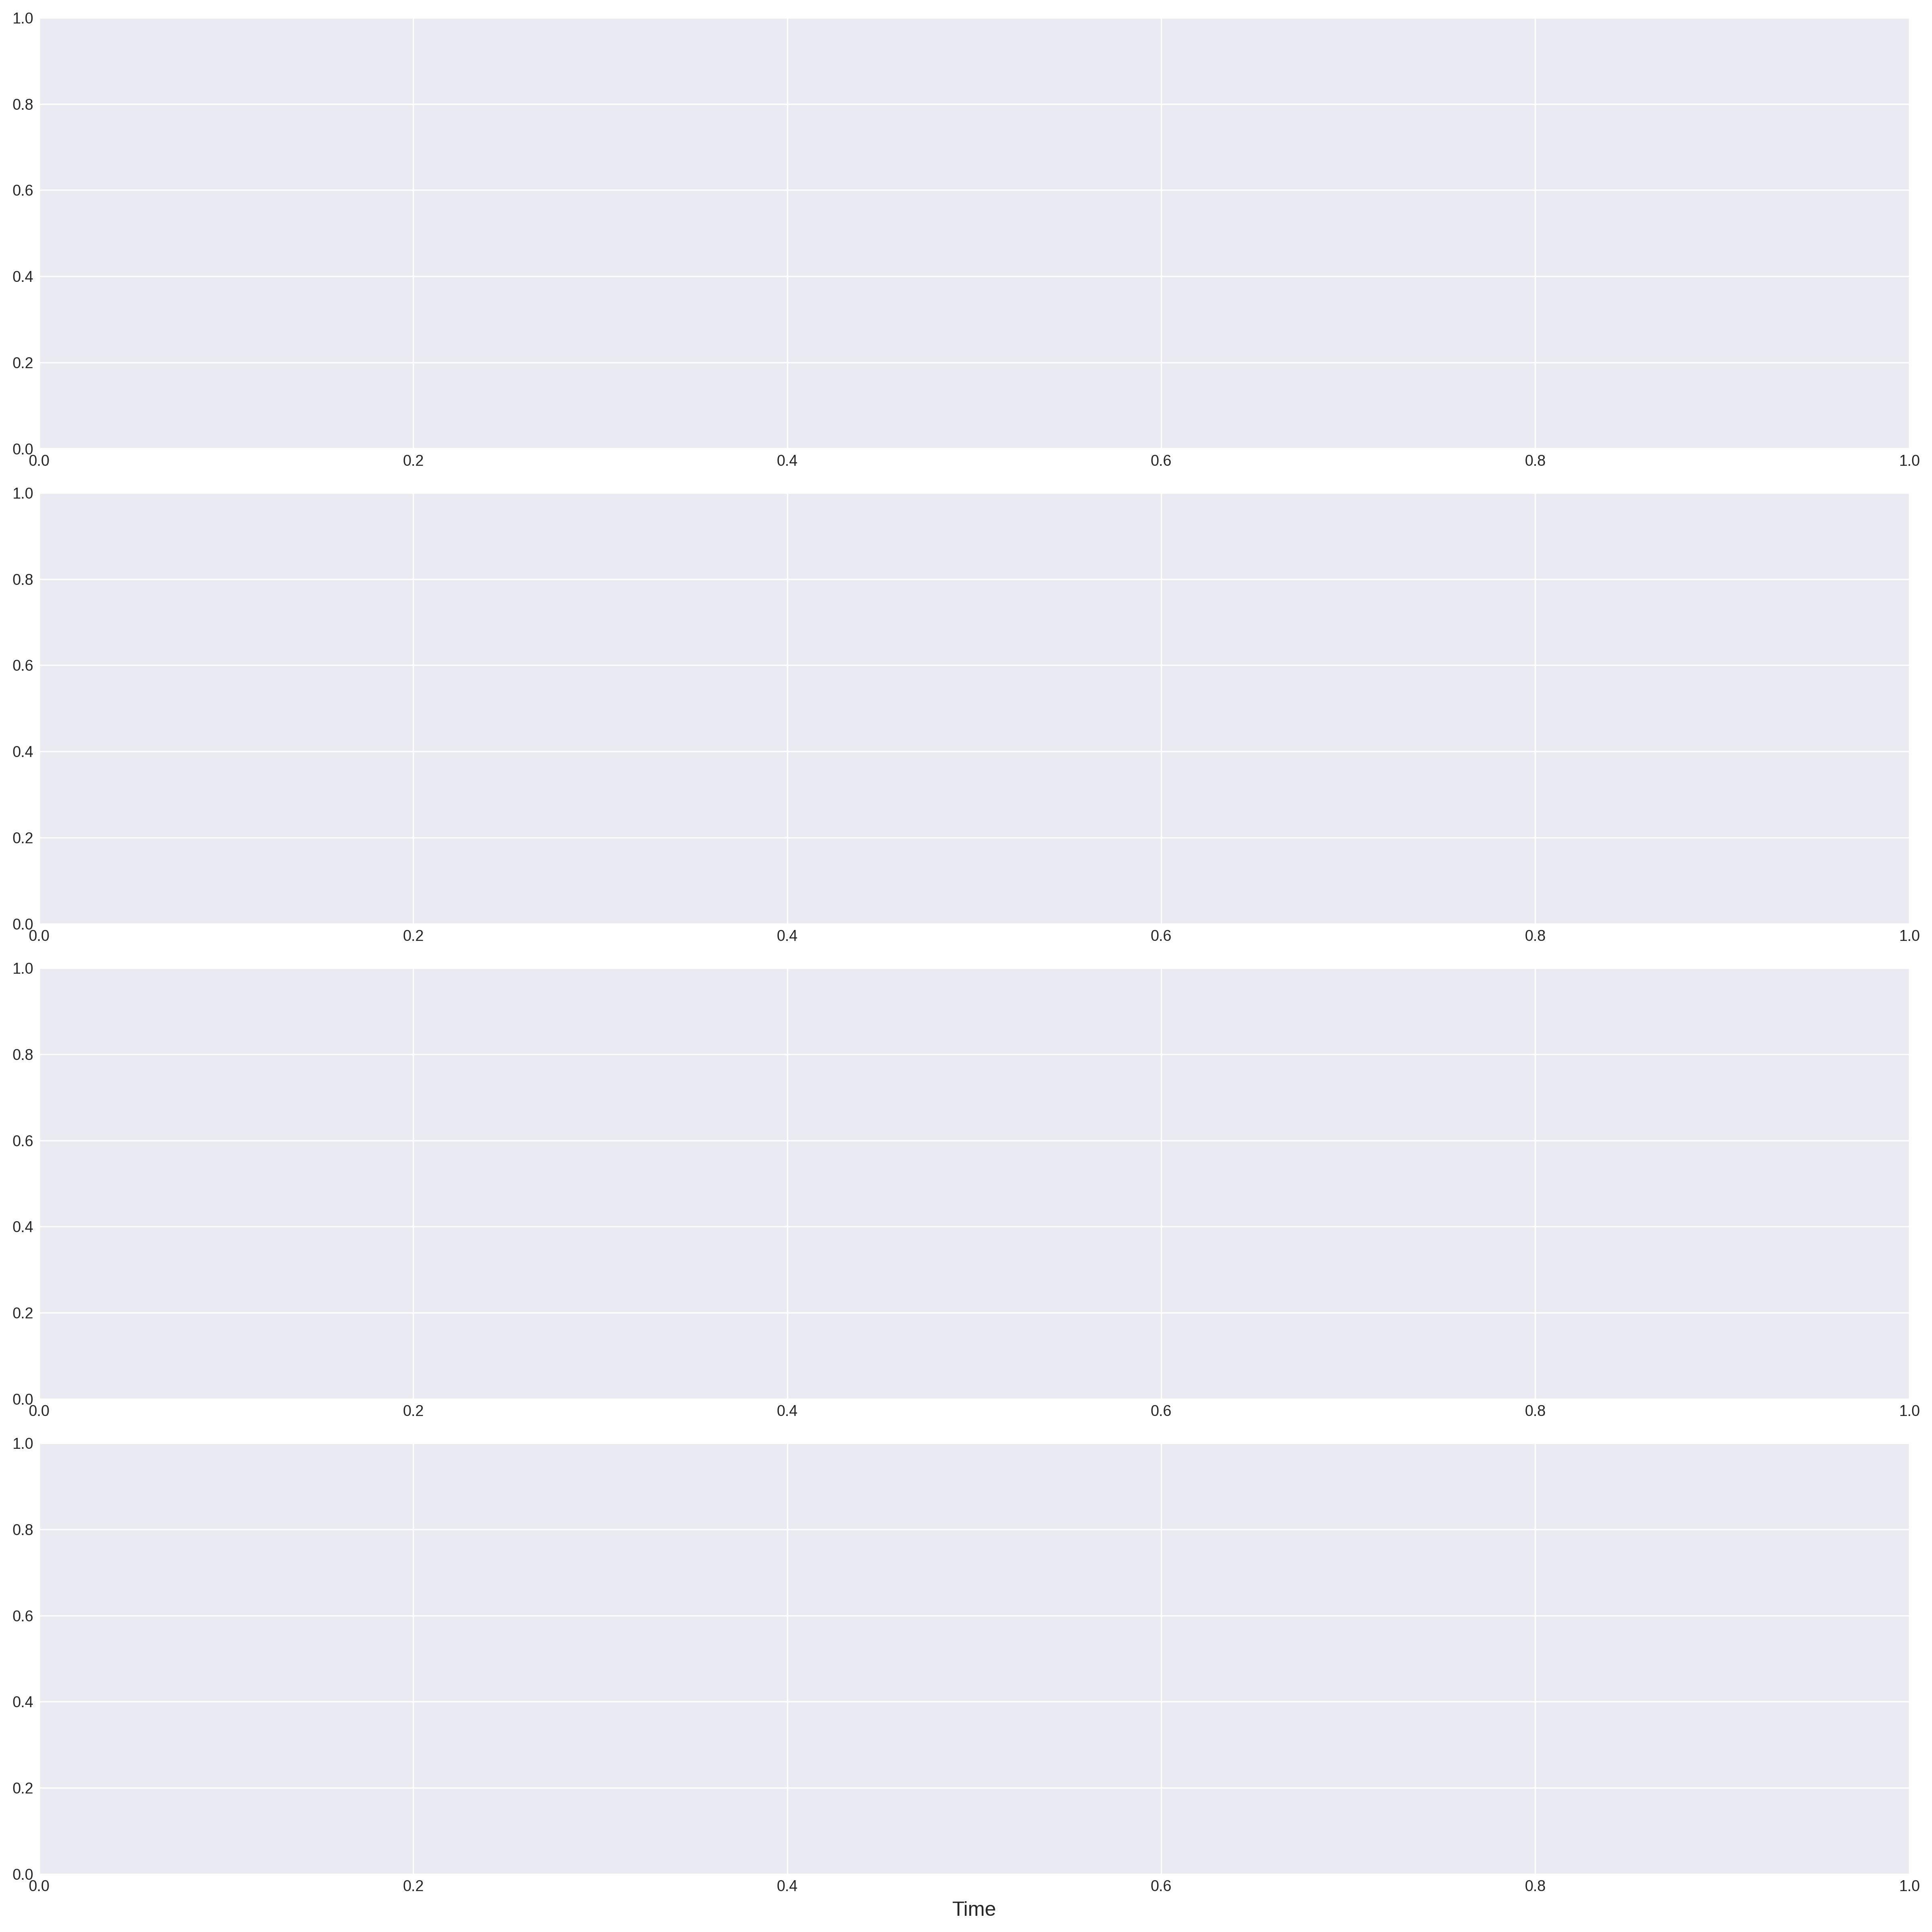

  Saved: fig10_all_series_conditional_volatility.png

--------------------------------------------------------------------------------
CREATING CORRELATION HEATMAP
--------------------------------------------------------------------------------


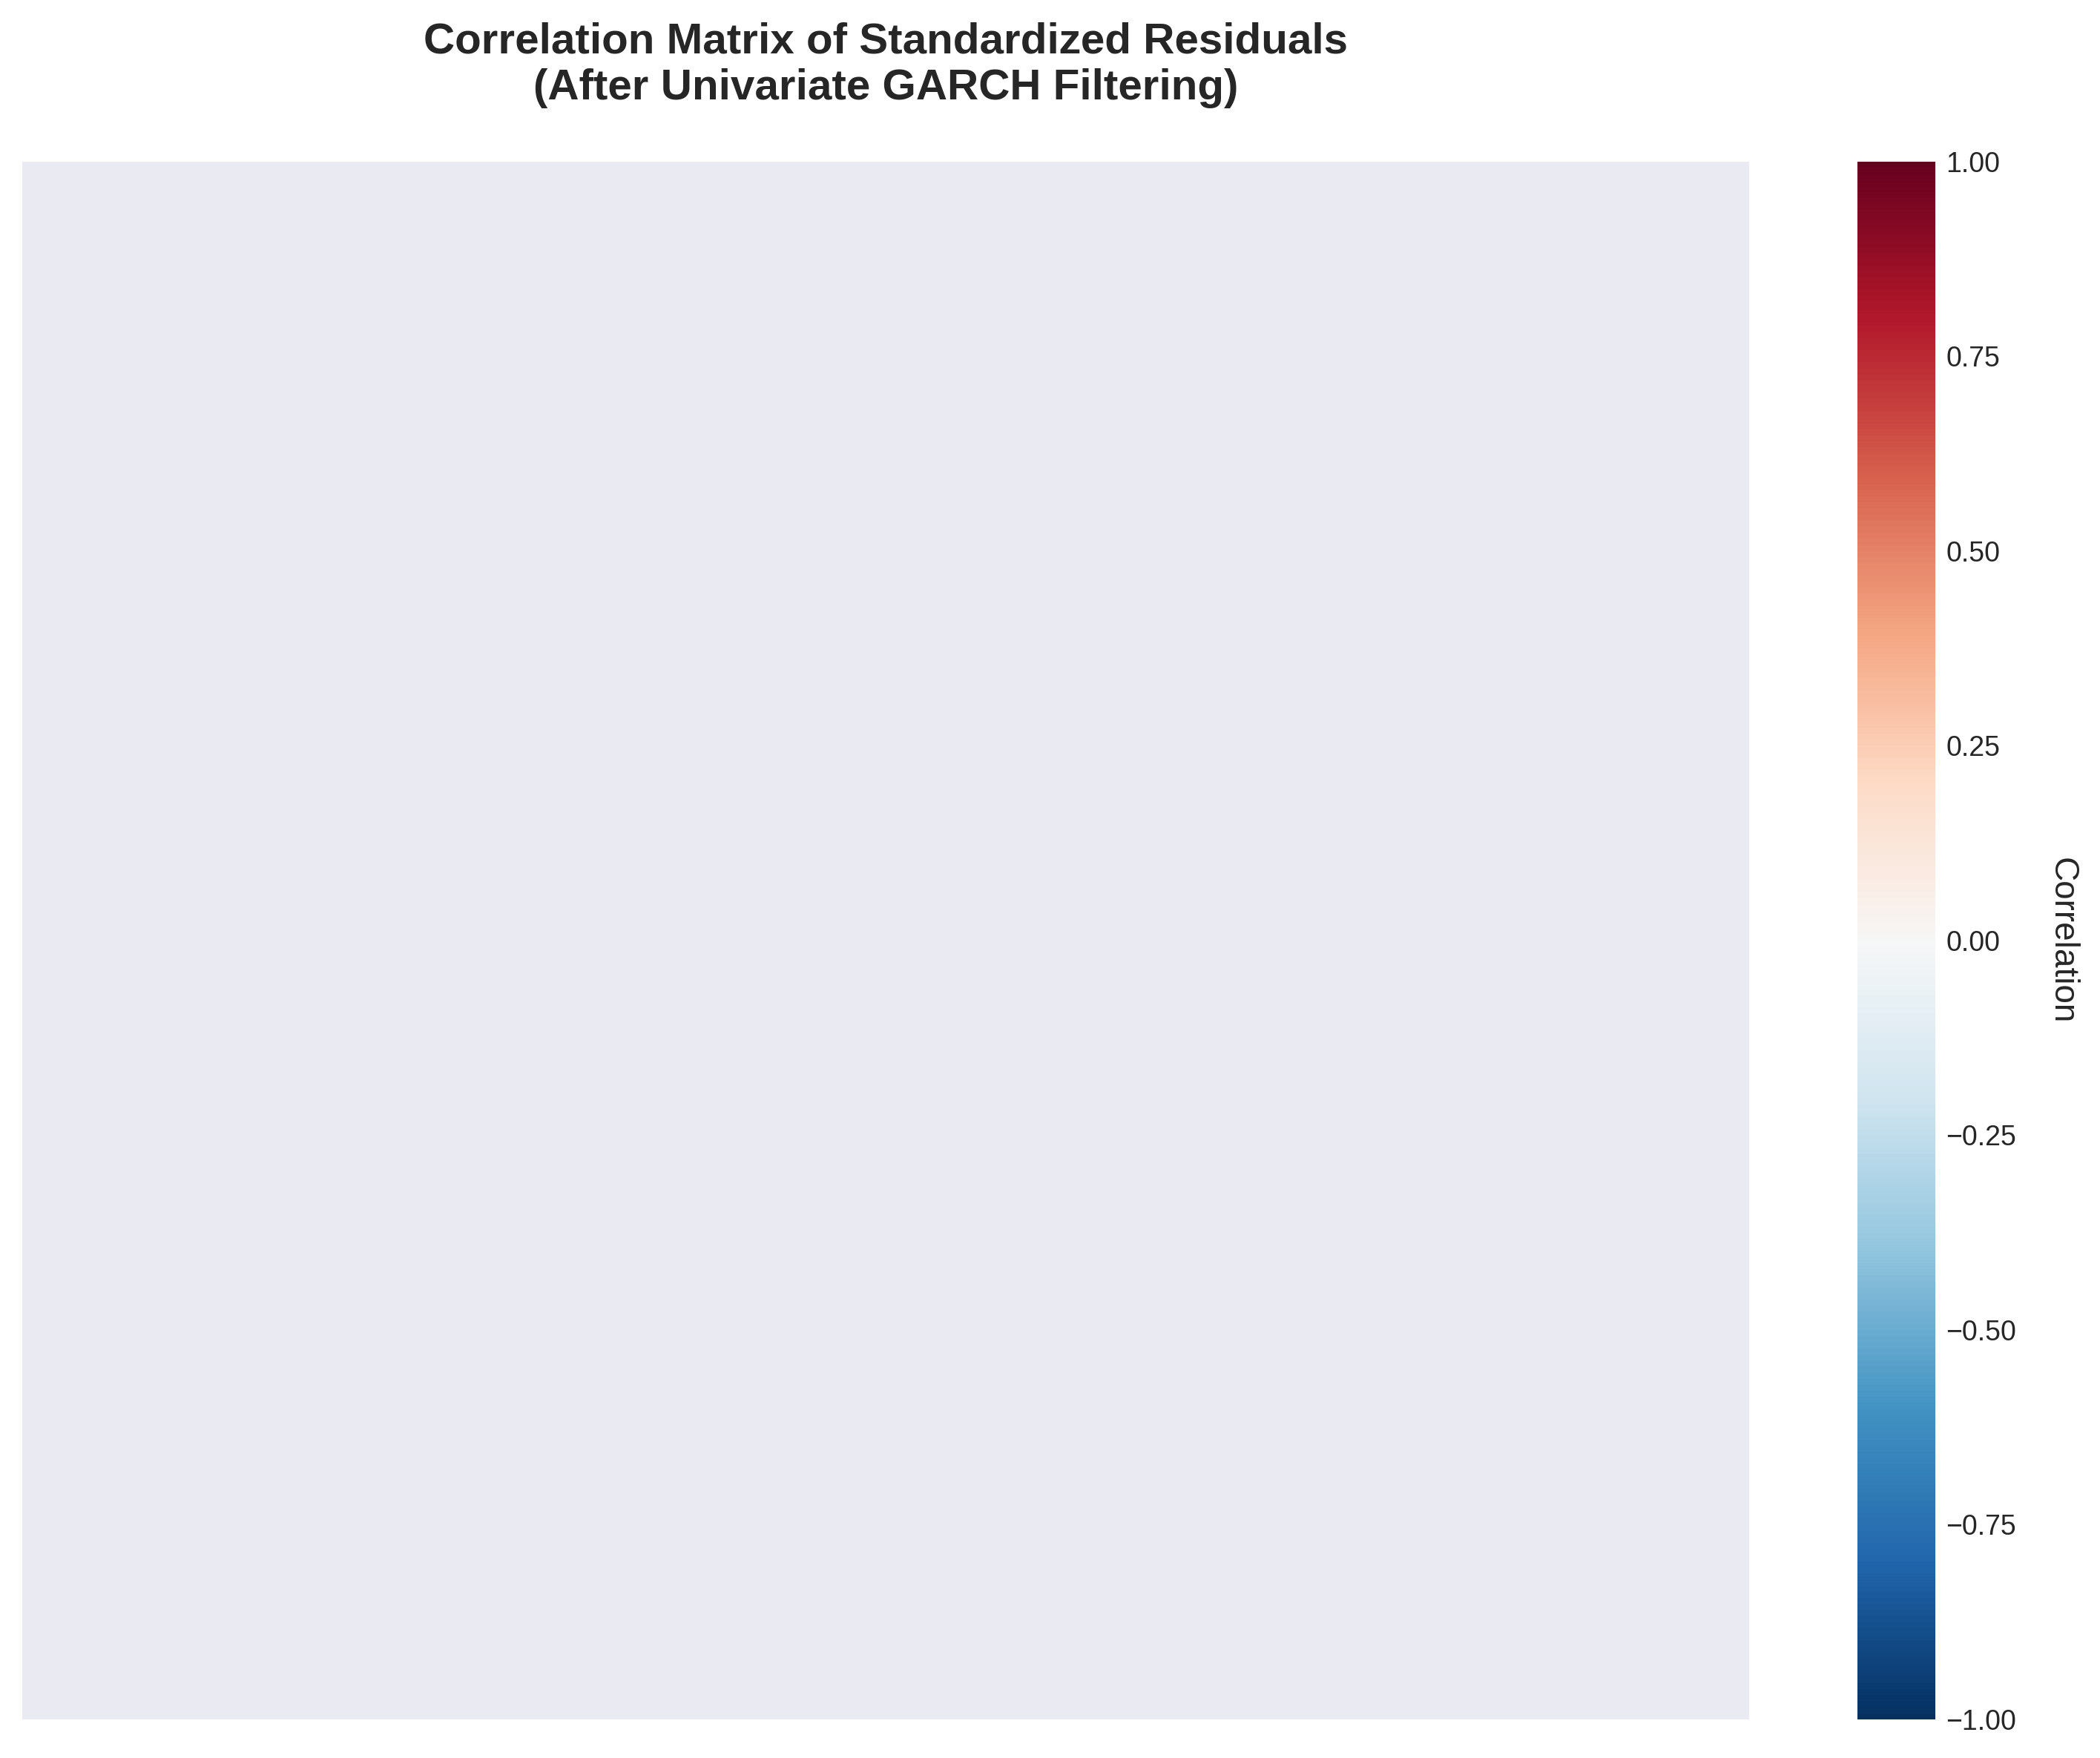

  Saved: fig11_residual_correlations_heatmap.png

INTERPRETATION & NEXT STEPS

1. UNIVARIATE GARCH PERFORMANCE:
   Successfully fitted 0/4 models

2. RESIDUAL CORRELATIONS:

3. NEXT STEPS:
   ✓ If residual correlations > 0.1: GARCH-X models are justified
   ✓ Move to multivariate GARCH-X to model conditional volatility spillovers
   ✓ Compare GARCH-X forecasts to univariate GARCH forecasts

SECTION 6 COMPLETE


In [5]:
# =============================================================================
# SECTION 6: UNIVARIATE GARCH MODELS FOR ALL SERIES + RESIDUAL CORRELATIONS
# Fit GARCH to each series, then correlate residuals
# =============================================================================

from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 80)
print("SECTION 6: UNIVARIATE GARCH MODELS + RESIDUAL CORRELATIONS")
print("=" * 80)

# =============================================================================
# STEP 1: FIT GARCH(1,1) TO EACH TIME SERIES
# =============================================================================
print("\n" + "-" * 80)
print("STEP 1: FIT GJR-GARCH(1,1) TO EACH TIME SERIES")
print("-" * 80)

# Dictionary to store all results
univariate_results = {}
standardized_residuals = pd.DataFrame()

# List of series to model (using the returns created in Section 5)
series_to_model = {
    'SP500_Tech': 'SP500_Tech_Return',
    'VIX': 'VIX_Return',
    'FEAR': 'FEAR_Return',
    'FEAR_Orthogonal': 'FEAR_Orthogonal_Return'
}

# Fit GJR-GARCH(1,1) to each series
for series_name, column_name in series_to_model.items():
    print(f"\n{'='*80}")
    print(f"FITTING GJR-GARCH(1,1) TO: {series_name}")
    print(f"{'='*80}")

    try:
        # Get returns (already in percentage units from Section 5)
        returns = train_data_clean[column_name].dropna()

        print(f"\nData Summary:")
        print(f"  Observations: {len(returns)}")
        print(f"  Mean: {returns.mean():.4f}%")
        print(f"  Std: {returns.std():.4f}%")
        print(f"  Min: {returns.min():.4f}%")
        print(f"  Max: {returns.max():.4f}%")

        # Fit GJR-GARCH(1,1) with Student's t (best model from Section 4)
        model = arch_model(
            returns,
            mean='Constant',
            vol='GARCH',
            p=1,
            o=1,  # GJR-GARCH
            q=1,
            dist='t'
        )
        result = model.fit(disp='off')
        univariate_results[series_name] = result

        # Extract standardized residuals (align with returns index)
        std_resid = result.std_resid
        standardized_residuals[series_name] = std_resid

        # Print results
        print("\n" + "-" * 80)
        print("ESTIMATION RESULTS:")
        print("-" * 80)
        print(f"\nLog-Likelihood: {result.loglikelihood:.2f}")
        print(f"AIC: {result.aic:.2f}")
        print(f"BIC: {result.bic:.2f}")

        print("\nVolatility Model Parameters:")
        print(f"  Omega:  {result.params['omega']:.6f}")
        print(f"  Alpha:  {result.params['alpha[1]']:.6f}")
        print(f"  Gamma:  {result.params['gamma[1]']:.6f}")
        print(f"  Beta:   {result.params['beta[1]']:.6f}")

        # Calculate persistence
        alpha = result.params['alpha[1]']
        gamma = result.params['gamma[1]']
        beta = result.params['beta[1]']
        persistence = alpha + gamma/2 + beta

        print(f"\nPersistence (α + γ/2 + β): {persistence:.6f}")
        if persistence >= 1.0:
            print("  WARNING: Non-stationary (persistence >= 1.0)")
        elif persistence > 0.98:
            print("  WARNING: Very high persistence (> 0.98)")
        elif persistence > 0.95:
            print("  High persistence (> 0.95) - typical for financial data")
        else:
            print("  Persistence < 0.95 (stable)")

        # Asymmetry interpretation
        if gamma > 0:
            print(f"\n  Leverage effect present: Gamma = {gamma:.4f} > 0")
            print(f"    Negative shocks increase volatility by {gamma:.4f} more than positive shocks")
        else:
            print(f"\n  No leverage effect: Gamma = {gamma:.4f}")

        print(f"\n{series_name} MODEL SUCCESSFUL")

    except Exception as e:
        print(f"\nERROR fitting {series_name}: {e}")
        univariate_results[series_name] = None

# =============================================================================
# STEP 2: CREATE COMPARISON TABLE
# =============================================================================
print("\n" + "=" * 80)
print("STEP 2: MODEL COMPARISON ACROSS ALL SERIES")
print("=" * 80)

comparison_list = []
for series_name, result in univariate_results.items():
    if result is not None:
        comparison_list.append({
            'Series': series_name,
            'Log-Likelihood': result.loglikelihood,
            'AIC': result.aic,
            'BIC': result.bic,
            'Omega': result.params['omega'],
            'Alpha': result.params['alpha[1]'],
            'Gamma': result.params['gamma[1]'],
            'Beta': result.params['beta[1]'],
            'Persistence': result.params['alpha[1]'] + result.params['gamma[1]']/2 + result.params['beta[1]']
        })

comparison_df = pd.DataFrame(comparison_list)
print("\n", comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv(f'{results_dir}/univariate_garch_comparison.csv', index=False)
print(f"\nSaved: univariate_garch_comparison.csv")

# =============================================================================
# STEP 3: STANDARDIZED RESIDUALS CORRELATION ANALYSIS
# =============================================================================
print("\n" + "=" * 80)
print("STEP 3: STANDARDIZED RESIDUALS CORRELATION ANALYSIS")
print("=" * 80)

# Drop any rows with missing values
standardized_residuals_clean = standardized_residuals.dropna()

print(f"\nStandardized residuals shape: {standardized_residuals_clean.shape}")
print(f"Observations: {len(standardized_residuals_clean)}")

# Compute correlation matrix
residual_correlations = standardized_residuals_clean.corr()

print("\n" + "-" * 80)
print("CORRELATION MATRIX OF STANDARDIZED RESIDUALS:")
print("-" * 80)
print("\n", residual_correlations.round(4).to_string())

# Save correlation matrix
residual_correlations.to_csv(f'{results_dir}/standardized_residuals_correlations.csv')
print(f"\nSaved: standardized_residuals_correlations.csv")

# =============================================================================
# STEP 4: VISUALIZATION - CONDITIONAL VOLATILITY FOR ALL SERIES
# =============================================================================
# =============================================================================
# STEP 4: VISUALIZATION - CONDITIONAL VOLATILITY FOR ALL SERIES
# =============================================================================
print("\n" + "=" * 80)
print("STEP 4: CREATING VISUALIZATIONS")
print("=" * 80)

# Create 4-panel plot with conditional volatility for each series
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

for idx, (series_name, column_name) in enumerate(series_to_model.items()):
    if series_name in univariate_results and univariate_results[series_name] is not None:
        result = univariate_results[series_name]

        # Get conditional volatility and aligned returns from GARCH result
        conditional_vol = result.conditional_volatility
        returns_aligned = result.resid + result.params['mu']  # Reconstruct returns

        # Plot returns with shaded volatility bands
        axes[idx].plot(returns_aligned, label='Returns', color='blue', alpha=0.6, linewidth=0.8)
        upper_bound = 2 * conditional_vol
        lower_bound = -2 * conditional_vol
        axes[idx].fill_between(
            range(len(returns_aligned)),
            lower_bound,
            upper_bound,
            color='red',
            alpha=0.2,
            label='±2 Conditional Std Dev'
        )
        axes[idx].axhline(0, color='black', linestyle='--', linewidth=0.5)
        axes[idx].set_title(f'{series_name}: Returns with Conditional Volatility Bands',
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Returns / Volatility (%)')
        axes[idx].legend(loc='upper right')
        axes[idx].grid(True, alpha=0.3)

plt.xlabel('Time', fontsize=12)
plt.tight_layout()
plt.savefig(f'{results_dir}/fig10_all_series_conditional_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"  Saved: fig10_all_series_conditional_volatility.png")


# =============================================================================
# STEP 5: HEATMAP OF RESIDUAL CORRELATIONS
# =============================================================================
print("\n" + "-" * 80)
print("CREATING CORRELATION HEATMAP")
print("-" * 80)

fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
im = ax.imshow(residual_correlations, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(len(residual_correlations.columns)))
ax.set_yticks(np.arange(len(residual_correlations.index)))
ax.set_xticklabels(residual_correlations.columns, rotation=45, ha='right')
ax.set_yticklabels(residual_correlations.index)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation', rotation=270, labelpad=20)

# Add text annotations
for i in range(len(residual_correlations.index)):
    for j in range(len(residual_correlations.columns)):
        text = ax.text(j, i, f'{residual_correlations.iloc[i, j]:.3f}',
                      ha='center', va='center', color='black', fontsize=10)

ax.set_title('Correlation Matrix of Standardized Residuals\n(After Univariate GARCH Filtering)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{results_dir}/fig11_residual_correlations_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"  Saved: fig11_residual_correlations_heatmap.png")

# =============================================================================
# STEP 6: INTERPRETATION & NEXT STEPS
# =============================================================================
print("\n" + "=" * 80)
print("INTERPRETATION & NEXT STEPS")
print("=" * 80)

print("\n1. UNIVARIATE GARCH PERFORMANCE:")
success_count = sum(1 for v in univariate_results.values() if v is not None)
print(f"   Successfully fitted {success_count}/{len(series_to_model)} models")

print("\n2. RESIDUAL CORRELATIONS:")
# Get correlations with SP500_Tech (excluding diagonal)
if 'SP500_Tech' in residual_correlations.columns:
    sp500_correlations = residual_correlations['SP500_Tech'].drop('SP500_Tech')
    print(f"\n   Correlations with SP500_Tech standardized residuals:")
    for series, corr in sp500_correlations.items():
        print(f"     {series}: {corr:.4f}")
        if abs(corr) > 0.3:
            print(f"       → STRONG correlation! GARCH-X likely beneficial")
        elif abs(corr) > 0.1:
            print(f"       → MODERATE correlation, GARCH-X may help")
        else:
            print(f"       → WEAK correlation")

print("\n3. NEXT STEPS:")
print("   ✓ If residual correlations > 0.1: GARCH-X models are justified")
print("   ✓ Move to multivariate GARCH-X to model conditional volatility spillovers")
print("   ✓ Compare GARCH-X forecasts to univariate GARCH forecasts")

print("\n" + "=" * 80)
print("SECTION 6 COMPLETE")
print("=" * 80)


# Section 7: GARCH-X on R-studio

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


# =============================================================================
# EXPORT PREPROCESSED DATA FOR R GARCH-X ANALYSIS
# =============================================================================


print("="*80)
print("EXPORTING PREPROCESSED DATA FOR R ANALYSIS")
print("="*80)


# Load your clean dataset
df = pd.read_csv("thesis_dataset_clean.csv", parse_dates=['Date'])
print(f"\nTotal dataset: {len(df)} observations")


# 80-20 Split (same as before)
split_idx = int(len(df) * 0.8)
train_data = df.iloc[:split_idx].copy()
test_data = df.iloc[split_idx:].copy()


print(f"Train: {len(train_data)} obs ({train_data['Date'].min().date()} to {train_data['Date'].max().date()})")
print(f"Test:  {len(test_data)} obs ({test_data['Date'].min().date()} to {test_data['Date'].max().date()})")


# =============================================================================
# VERIFY ORTHOGONALIZATION
# =============================================================================


if 'FearOrth' not in train_data.columns:
    print("\nWARNING: FearOrth missing - re-run Section 2 to regenerate thesis_dataset_clean.csv properly")
    raise ValueError("thesis_dataset_clean.csv is outdated - regenerate from Section 2")
else:
    print(f"\nFearOrth verified (corr with VIX in train: {train_data[['VIXScaled','FearOrth']].corr().iloc[0,1]:.6f})")


# =============================================================================
# EXPORT TRAINING DATA FOR R
# =============================================================================


train_export = train_data[[
    'Date',
    'Log_Return',
    'VIXScaled',
    'FearScaled',
    'FearOrth'
]].copy()

train_export = train_export.dropna()
train_export.to_csv("train_data_for_R.csv", index=False)
print(f"\nEXPORTED: train_data_for_R.csv ({len(train_export)} rows)")
print(f"   Columns: {list(train_export.columns)}")


# =============================================================================
# EXPORT TEST DATA FOR R
# =============================================================================


test_export = test_data[[
    'Date',
    'Log_Return',
    'VIXScaled',
    'FearScaled',
    'FearOrth'
]].copy()

test_export = test_export.dropna()
test_export.to_csv("test_data_for_R.csv", index=False)
print(f"\nEXPORTED: test_data_for_R.csv ({len(test_export)} rows)")


# =============================================================================
# EXPORT FULL DATASET
# =============================================================================


full_export = df[[
    'Date',
    'XLK_price',
    'Log_Return',
    'VIX',
    'VIXScaled',
    'FNG',
    'FearIndex',
    'FearScaled',
    'FearOrth'
]].copy()

full_export = full_export.dropna()
full_export['TrainTest'] = ['Train' if i < split_idx else 'Test' for i in range(len(full_export))]
full_export.to_csv("full_dataset_for_R.csv", index=False)
print(f"\nEXPORTED: full_dataset_for_R.csv ({len(full_export)} rows)")


# =============================================================================
# SUMMARY STATISTICS FOR VERIFICATION
# =============================================================================


print("\n" + "="*80)
print("TRAINING DATA SUMMARY (for R verification)")
print("="*80)

summary_stats = train_export[['Log_Return', 'VIXScaled', 'FearOrth']].describe()
print(summary_stats)

print("\nCorrelations (Training Data):")
corr_matrix = train_export[['Log_Return', 'VIXScaled', 'FearOrth']].corr()
print(corr_matrix)

print("\n" + "="*80)
print("FILES READY FOR R ANALYSIS")
print("="*80)
print("\nFiles exported:")
print("  1. train_data_for_R.csv     - Use for GJR-GARCH-X estimation in R")
print("  2. test_data_for_R.csv      - Use for out-of-sample forecasting in R")
print("  3. full_dataset_for_R.csv   - Complete dataset with train/test flag")
print("\nVariables in train_data_for_R.csv:")
print("  - Log_Return:  XLK log returns (target variable)")
print("  - VIXScaled:   Standardized VIX (external regressor)")
print("  - FearOrth:    Orthogonalized Fear (external regressor)")
print("\nNext: Load train_data_for_R.csv in R and fit GJR-GARCH-X models")
print("="*80)


EXPORTING PREPROCESSED DATA FOR R ANALYSIS

Total dataset: 3247 observations
Train: 2597 obs (2011-01-04 to 2021-06-01)
Test:  650 obs (2021-06-02 to 2023-12-29)

FearOrth verified (corr with VIX in train: -0.000000)

EXPORTED: train_data_for_R.csv (2597 rows)
   Columns: ['Date', 'Log_Return', 'VIXScaled', 'FearScaled', 'FearOrth']

EXPORTED: test_data_for_R.csv (650 rows)

EXPORTED: full_dataset_for_R.csv (3247 rows)

TRAINING DATA SUMMARY (for R verification)
        Log_Return     VIXScaled      FearOrth
count  2597.000000  2.597000e+03  2.597000e+03
mean      0.000689  2.188811e-17  2.188811e-17
std       0.012886  1.000000e+00  9.127004e-01
min      -0.148662 -1.151593e+00 -2.109264e+00
25%      -0.004603 -6.103137e-01 -7.000469e-01
50%       0.001019 -2.767982e-01 -5.413211e-02
75%       0.006715  2.685818e-01  6.966665e-01
max       0.110932  8.901714e+00  2.209646e+00

Correlations (Training Data):
            Log_Return     VIXScaled      FearOrth
Log_Return    1.000000 -1.43